In [12]:
import os, sys, warnings, logging, json, time, gc
from copy import deepcopy
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yaml
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from stable_baselines3.common.vec_env import DummyVecEnv
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('.')
CONFIGS_DIR  = PROJECT_ROOT / 'configs'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results'
RESULTS_EVAL = RESULTS_DIR / 'evaluation'
PLOTS_DIR    = RESULTS_DIR / 'plots'
for d in [MODELS_DIR, RESULTS_EVAL, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Device + seed ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Device: {DEVICE}')

# ── Load configs ──────────────────────────────────────────────────────────────
with open(CONFIGS_DIR / 'environment.yaml') as f:
    ENV_CONFIG = yaml.safe_load(f)

with open(CONFIGS_DIR / 'features.yaml') as f:
    FEAT_CONFIG = yaml.safe_load(f)

with open(CONFIGS_DIR / 'best_ppo_hparams.yaml') as f:
    BEST_HPO_HPARAMS = yaml.safe_load(f)
# Fix normalize_advantage serialization bug
BEST_HPO_HPARAMS['normalize_advantage'] = bool(BEST_HPO_HPARAMS.get('normalize_advantage', True))

with open(CONFIGS_DIR / 'best_env_config.yaml') as f:
    BEST_ENV_CONFIG = yaml.safe_load(f)

ALL_FEATURES    = FEAT_CONFIG['all_features']
REGIME_FEATURES = FEAT_CONFIG['regime_features']
LOOKBACK        = FEAT_CONFIG['lookback_window']
N_FEATURES      = FEAT_CONFIG['n_features']
REGIME_IDX      = [ALL_FEATURES.index(f) for f in REGIME_FEATURES]

# ── Load data ─────────────────────────────────────────────────────────────────
wti_df = pd.read_parquet(PROJECT_ROOT / 'data' / 'features' / 'WTI_Crude_Oil_features.parquet')
wti_df = wti_df.dropna(subset=ALL_FEATURES + ['log_return', 'close'])
print(f'WTI data: {len(wti_df)} rows | {wti_df.index[0].date()} to {wti_df.index[-1].date()}')

# ── Walk-forward splits ───────────────────────────────────────────────────────
def make_wf_splits(df, train_years=3, test_years=1):
    dates = df.index.sort_values()
    start, end = dates[0], dates[-1]
    splits = []
    t = start + pd.DateOffset(years=train_years)
    while t + pd.DateOffset(years=test_years) <= end + pd.DateOffset(days=1):
        splits.append({
            'train_start': str(start.date()),
            'train_end'  : str(t.date()),
            'test_start' : str(t.date()),
            'test_end'   : str(min(t + pd.DateOffset(years=test_years),
                                   end + pd.DateOffset(days=1)).date())
        })
        t += pd.DateOffset(years=test_years)
    return splits

WF_SPLITS = make_wf_splits(wti_df)
print(f'Walk-forward splits: {len(WF_SPLITS)}')
for i, s in enumerate(WF_SPLITS):
    print(f'  Split {i}: train {s["train_start"]} to {s["train_end"]} | '
          f'test {s["test_start"]} to {s["test_end"]}')

# ── Verification summary ──────────────────────────────────────────────────────
print(f'\nBest HPO config loaded:')
print(f'  learning_rate  : {BEST_HPO_HPARAMS["learning_rate"]:.2e}')
print(f'  n_steps        : {BEST_HPO_HPARAMS["n_steps"]}')
print(f'  n_epochs       : {BEST_HPO_HPARAMS["n_epochs"]}')
print(f'  gamma          : {BEST_HPO_HPARAMS["gamma"]:.4f}')
print(f'Best reward weights:')
print(f'  w_return       : {BEST_ENV_CONFIG["w_return"]:.4f}')
print(f'  w_sharpe       : {BEST_ENV_CONFIG["w_sharpe"]:.4f}')
print(f'  w_drawdown     : {BEST_ENV_CONFIG["w_drawdown"]:.4f}')
print(f'  w_transaction  : {BEST_ENV_CONFIG["w_transaction"]:.4f}')


Device: cuda
WTI data: 4965 rows | 2005-12-21 to 2024-12-31
Walk-forward splits: 16
  Split 0: train 2005-12-21 to 2008-12-21 | test 2008-12-21 to 2009-12-21
  Split 1: train 2005-12-21 to 2009-12-21 | test 2009-12-21 to 2010-12-21
  Split 2: train 2005-12-21 to 2010-12-21 | test 2010-12-21 to 2011-12-21
  Split 3: train 2005-12-21 to 2011-12-21 | test 2011-12-21 to 2012-12-21
  Split 4: train 2005-12-21 to 2012-12-21 | test 2012-12-21 to 2013-12-21
  Split 5: train 2005-12-21 to 2013-12-21 | test 2013-12-21 to 2014-12-21
  Split 6: train 2005-12-21 to 2014-12-21 | test 2014-12-21 to 2015-12-21
  Split 7: train 2005-12-21 to 2015-12-21 | test 2015-12-21 to 2016-12-21
  Split 8: train 2005-12-21 to 2016-12-21 | test 2016-12-21 to 2017-12-21
  Split 9: train 2005-12-21 to 2017-12-21 | test 2017-12-21 to 2018-12-21
  Split 10: train 2005-12-21 to 2018-12-21 | test 2018-12-21 to 2019-12-21
  Split 11: train 2005-12-21 to 2019-12-21 | test 2019-12-21 to 2020-12-21
  Split 12: train 2005-12-

In [13]:
# At the very top of cell 4, before any function definitions
TRAIN_STEPS_BY_AGENT = {
    'ara_ppo'              : 500_000,
    'standard_ppo'         : 200_000,
    'no_adaptive_clip'     : 500_000,
    'no_regime_critic'     : 500_000,
    'transformer_ara_ppo'  : 500_000,
}

class CommodityTradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, df, features, config, mode='train', scaler=None, render_mode=None):
        super().__init__()
        self.df = df.copy()
        self.features = features
        self.config = config
        self.mode = mode
        self.render_mode = render_mode
        missing = [f for f in features if f not in df.columns]
        if missing:
            raise ValueError(f'Missing features: {missing}')
        self.n_features = len(features)
        self.lookback = config['lookback_window']
        self.episode_length = config['episode_length']
        self.n_rows = len(df)
        self.min_rows = self.lookback + self.episode_length
        if self.n_rows < self.min_rows:
            raise ValueError(f'Need {self.min_rows} rows, got {self.n_rows}')
        if scaler is None:
            self.scaler = RobustScaler()
            self.scaler.fit(df[features].values)
        else:
            self.scaler = scaler
        scaled = self.scaler.transform(df[features].values)
        self.features_arr = np.clip(scaled, -config['clip_obs'], config['clip_obs']).astype(np.float32)
        self.close_arr  = df['close'].values.astype(np.float32)
        self.return_arr = df['log_return'].fillna(0).values.astype(np.float32)
        obs_dim = self.lookback * self.n_features + 5
        self.observation_space = gym.spaces.Box(
            low=-config['clip_obs'], high=config['clip_obs'],
            shape=(obs_dim,), dtype=np.float32)
        self.action_space = gym.spaces.Box(
            low=np.array([config['action_min']], dtype=np.float32),
            high=np.array([config['action_max']], dtype=np.float32),
            shape=(1,), dtype=np.float32)
        self._init_state()

    def _init_state(self):
        self.current_step = 0
        self.start_idx = 0
        self.portfolio_value = float(self.config['initial_capital'])
        self.cash = self.portfolio_value
        self.position = 0.0
        self.peak_value = self.portfolio_value
        self.total_costs = 0.0
        self.trade_count = 0
        self.return_history = []
        self.value_history  = [self.portfolio_value]
        self.action_history = []
        self.reward_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        max_start = self.n_rows - self.episode_length - self.lookback
        if self.mode == 'train':
            self.start_idx = int(self.np_random.integers(0, max(1, max_start)))
        else:
            self.start_idx = 0
        self._init_state()
        return self._get_observation(), self._get_info()

    def step(self, action):
        new_pos = float(np.clip(action[0], self.config['action_min'], self.config['action_max']))
        max_change = self.config['position_change_limit']
        delta = np.clip(new_pos - self.position, -max_change, max_change)
        new_pos = self.position + delta
        cost = self._compute_cost(self.position, new_pos)
        data_idx = self.start_idx + self.lookback + self.current_step
        market_ret = float(self.return_arr[min(data_idx, len(self.return_arr)-1)])
        port_ret = self.position * market_ret - cost
        new_val = self.portfolio_value * (1 + port_ret)
        self.position = new_pos
        self.portfolio_value = new_val
        self.peak_value = max(self.peak_value, new_val)
        self.total_costs += cost * self.portfolio_value
        self.trade_count += 1 if abs(delta) > 0.01 else 0
        reward = self._compute_reward(port_ret, cost)
        self.return_history.append(port_ret)
        self.value_history.append(self.portfolio_value)
        self.action_history.append(new_pos)
        self.reward_history.append(reward)
        self.current_step += 1
        truncated  = self.current_step >= self.episode_length
        terminated = self._check_termination()
        return self._get_observation(), reward, terminated, truncated, self._get_info()

    def _compute_cost(self, old_pos, new_pos):
        trade_size = abs(new_pos - old_pos)
        if trade_size < 1e-6:
            return 0.0
        cost = trade_size * (
            self.config['commission_per_trade'] +
            self.config['bid_ask_spread'] +
            self.config['slippage']
        )
        if self.current_step % 21 == 0 and abs(new_pos) > 0.01:
            cost += abs(new_pos) * self.config['roll_cost']
        return float(cost)

    def _compute_reward(self, port_ret, cost):
        cfg = self.config
        r_return = port_ret
        drawdown = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        r_drawdown = min(drawdown, 0.0)
        r_transaction = -cost
        r_sharpe = 0.0
        w = cfg['sharpe_window']
        if len(self.return_history) >= w:
            rets = np.array(self.return_history[-w:])
            r_sharpe = np.clip(rets.mean() / (rets.std() + 1e-10) * np.sqrt(252/w), -5.0, 5.0)
        reward = (
            cfg['w_return']      * r_return +
            cfg['w_drawdown']    * r_drawdown +
            cfg['w_transaction'] * r_transaction +
            cfg['w_sharpe']      * r_sharpe * 0.01
        ) * cfg['reward_scaling']
        return float(reward)

    def _check_termination(self):
        if self.peak_value <= 0:
            return True
        return (self.portfolio_value / self.peak_value - 1) < self.config['max_drawdown_limit']

    def _get_observation(self):
        start = self.start_idx + self.current_step
        end   = min(start + self.lookback, len(self.features_arr))
        start = max(0, end - self.lookback)
        feat_window = self.features_arr[start:end]
        if len(feat_window) < self.lookback:
            pad = np.zeros((self.lookback - len(feat_window), self.n_features), dtype=np.float32)
            feat_window = np.vstack([pad, feat_window])
        drawdown = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        log_pnl  = np.log(self.portfolio_value / self.config['initial_capital'] + 1e-10)
        port_state = np.array([
            self.position,
            np.clip(drawdown, -1.0, 0.0),
            np.clip(log_pnl, -5.0, 5.0),
            self.current_step / self.episode_length,
            np.clip(self.total_costs / self.config['initial_capital'], 0, 0.1)
        ], dtype=np.float32)
        return np.concatenate([feat_window.flatten(), port_state]).astype(np.float32)

    def _get_info(self):
        dd = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        tr = self.portfolio_value / self.config['initial_capital'] - 1
        sharpe = 0.0
        if len(self.return_history) >= self.config['sharpe_window']:
            rets = np.array(self.return_history)
            sharpe = rets.mean() / (rets.std() + 1e-10) * np.sqrt(252)
        return {
            'step': self.current_step, 'portfolio_value': self.portfolio_value,
            'position': self.position, 'total_return': tr,
            'drawdown': dd, 'sharpe': sharpe,
            'total_costs': self.total_costs, 'trade_count': self.trade_count
        }

    def get_episode_metrics(self):
        values  = np.array(self.value_history)
        returns = np.array(self.return_history)
        if len(returns) < 2:
            return {}
        total_return = values[-1] / values[0] - 1
        n_days    = len(returns)
        ann_ret   = (1 + total_return) ** (252 / n_days) - 1
        ann_vol   = returns.std() * np.sqrt(252)
        sharpe    = ann_ret / (ann_vol + 1e-10)
        peak      = np.maximum.accumulate(values)
        dd        = (values - peak) / (peak + 1e-10)
        max_dd    = dd.min()
        calmar    = ann_ret / (abs(max_dd) + 1e-10)
        neg_rets  = returns[returns < 0]
        down_std  = neg_rets.std() * np.sqrt(252) if len(neg_rets) > 0 else 1e-10
        sortino   = ann_ret / (down_std + 1e-10)
        win_rate  = (returns > 0).mean()
        return {
            'total_return': float(total_return), 'ann_return': float(ann_ret),
            'ann_vol': float(ann_vol), 'sharpe': float(sharpe),
            'max_drawdown': float(max_dd), 'calmar': float(calmar),
            'sortino': float(sortino), 'win_rate': float(win_rate),
            'total_costs': float(self.total_costs), 'trade_count': int(self.trade_count),
            'episode_length': int(len(returns))
        }

    def render(self): pass
    def close(self):  pass


class WalkForwardEnvFactory:
    def __init__(self, df, features, splits, config):
        self.df = df
        self.features = features
        self.splits = splits
        self.config = config

    def get_split(self, split_idx):
        split = self.splits[split_idx]
        train_df = self.df[
            (self.df.index >= split['train_start']) &
            (self.df.index <  split['train_end'])
        ].copy()
        test_df = self.df[
            (self.df.index >= split['test_start']) &
            (self.df.index <  split['test_end'])
        ].copy()
        scaler = RobustScaler()
        scaler.fit(train_df[self.features].values)
        test_cfg  = dict(self.config)
        train_cfg = dict(self.config)
        min_test_ep  = len(test_df)  - self.config['lookback_window']
        min_train_ep = len(train_df) - self.config['lookback_window']
        if min_test_ep < self.config['episode_length']:
            if min_test_ep < 20:
                return None, None, None
            test_cfg['episode_length'] = min_test_ep
        if min_train_ep < self.config['episode_length']:
            train_cfg['episode_length'] = min_train_ep
        train_env = CommodityTradingEnv(train_df, self.features, train_cfg, 'train', scaler)
        test_env  = CommodityTradingEnv(test_df,  self.features, test_cfg,  'test',  scaler)
        return train_env, test_env, scaler

    def n_splits(self): return len(self.splits)
class RegimeGatingLayer(nn.Module):
    """Learns to gate latent features based on 4 regime signals."""

    def __init__(self, n_regime: int, latent_dim: int):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(n_regime, latent_dim * 2),
            nn.Tanh(),
            nn.Linear(latent_dim * 2, latent_dim),
            nn.Sigmoid(),          # γ ∈ (0,1)^d
        )
        # Initialise close to 1 so early training is close to unregularised PPO
        nn.init.zeros_(self.gate[-2].bias)
        nn.init.normal_(self.gate[-2].weight, std=0.01)

    def forward(self, regime_signals: torch.Tensor, latent: torch.Tensor) -> torch.Tensor:
        gamma = self.gate(regime_signals)          # (B, latent_dim)
        # Bias toward 1: γ' = 0.5·γ + 0.5  ∈ (0.5, 1)
        gamma = 0.5 * gamma + 0.5
        return latent * gamma


class ResidualBlock(nn.Module):
    """Pre-norm residual block: LayerNorm → Linear → Activation → Linear + skip."""

    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)


class RegimeAwareExtractor(BaseFeaturesExtractor):
    """
    Custom SB3 feature extractor for ARA-PPO.

    Architecture
    ─────────────
    1. Flatten raw observation
    2. Main trunk: Linear(obs) → ResidualBlock × 2  → latent ∈ R^256
    3. Regime trunk: reads regime features → gating γ ∈ (0.5,1)^256
    4. Gated latent: z = latent * γ
    5. Return (z, regime_signals) packed into a flat vector
       SB3 expects a flat tensor; we cat z ‖ regime_signals.
    """

    # Indices of the 4 regime features inside the LAST lookback step
    # The obs layout is: feat_window.flatten() ‖ port_state (5)
    # feat_window[lookback-1, :] starts at index (lookback-1)*n_features

    def __init__(
        self,
        observation_space: gym.Space,
        latent_dim: int = 256,
        n_regime: int = 4,
        lookback: int = 60,
        n_features: int = 40,
        regime_idx: List[int] = None,
        dropout: float = 0.1,
    ):
        # features_dim is what SB3 passes to actor/critic heads
        features_dim = latent_dim + n_regime
        super().__init__(observation_space, features_dim=features_dim)

        self.latent_dim   = latent_dim
        self.n_regime     = n_regime
        self.lookback     = lookback
        self.n_features   = n_features
        # Offset to last-step features in flattened obs
        self._last_step_offset = (lookback - 1) * n_features
        self._regime_idx = regime_idx if regime_idx is not None else list(range(n_regime))

        obs_dim = int(np.prod(observation_space.shape))

        # ── Main trunk ────────────────────────────────────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(obs_dim, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.ELU(),
        )
        self.res_blocks = nn.Sequential(
            ResidualBlock(latent_dim, dropout),
            ResidualBlock(latent_dim, dropout),
        )
        self.post_norm = nn.LayerNorm(latent_dim)

        # ── Regime trunk & gating ─────────────────────────────────────────────────
        self.regime_gating = RegimeGatingLayer(n_regime, latent_dim)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def _extract_regime(self, obs: torch.Tensor) -> torch.Tensor:
        """Extract the 4 regime features from the most-recent timestep."""
        regime_vals = []
        for ri in self._regime_idx:
            col_idx = self._last_step_offset + ri
            regime_vals.append(obs[:, col_idx:col_idx+1])
        return torch.cat(regime_vals, dim=-1)   # (B, 4)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        regime_signals = self._extract_regime(observations)
        z = self.input_proj(observations)
        z = self.res_blocks(z)
        z = self.post_norm(z)
        z = self.regime_gating(regime_signals, z)         # gated latent
        return torch.cat([z, regime_signals], dim=-1)     # (B, latent+4)



class AdaptiveClipCallback(BaseCallback):
    """
    Modification 2: Adapt PPO clip_range based on regime_vol.

    At each rollout, reads regime_vol from the collected observations
    and adjusts clip_range for the next update.

    Parameters
    ----------
    eps_base   : float  – baseline clip value (default 0.2)
    alpha      : float  – sensitivity to regime_vol (default 0.5)
    eps_min    : float  – floor (default 0.05)
    eps_max    : float  – ceiling (default 0.4)
    regime_obs_idx : int – position of regime_vol in the flattened observation
    """

    def __init__(
        self,
        eps_base: float = 0.2,
        alpha: float = 0.5,
        eps_min: float = 0.05,
        eps_max: float = 0.40,
        regime_obs_idx: int = None,
        verbose: int = 0,
    ):
        super().__init__(verbose)
        self.eps_base       = eps_base
        self.alpha          = alpha
        self.eps_min        = eps_min
        self.eps_max        = eps_max
        self.regime_obs_idx = regime_obs_idx  # set externally if known
        self.clip_history   = []

    def _on_rollout_end(self) -> bool:
        """Called after rollout buffer is filled, before policy update."""
        # Read regime_vol from rollout buffer observations
        obs = self.model.rollout_buffer.observations   # (n_steps, n_envs, obs_dim)
        if self.regime_obs_idx is not None and obs is not None:
            regime_vol = obs[:, :, self.regime_obs_idx].mean()  # scalar
        else:
            # Fall-back: use last-step regime feature from extractor if available
            regime_vol = 0.0

        # Normalise: regime_vol is RobustScaler output, typically in [-5,5]
        # Map to [0,1] via sigmoid
        regime_vol_norm = float(torch.sigmoid(torch.tensor(float(regime_vol))).item())

        new_eps = self.eps_base * (1.0 + self.alpha * regime_vol_norm)
        new_eps = float(np.clip(new_eps, self.eps_min, self.eps_max))

        # SB3 clip_range is a callable; wrap scalar in a lambda
        self.model.clip_range = lambda _: new_eps
        self.clip_history.append(new_eps)

        if self.verbose >= 2:
            logger.info(f'AdaptiveClip: regime_vol={regime_vol:.3f} → ε={new_eps:.4f}')
        return True

    def _on_step(self) -> bool:
        return True




class RegimeDecomposedValueNet(nn.Module):
    """
    Modification 3: V(s) = V_base(s) + alpha_regime * V_regime(s)

    Installed as policy.value_net by ARAPPOPolicy._build().
    Input: full feature vector from extractor (latent + regime signals).
    """

    def __init__(self, features_dim: int, n_regime: int = 4, hidden: int = 128):
        super().__init__()
        self.v_base = nn.Sequential(
            nn.Linear(features_dim, hidden), nn.ELU(),
            nn.Linear(hidden, hidden // 2), nn.ELU(),
            nn.Linear(hidden // 2, 1),
        )
        self.v_regime = nn.Sequential(
            nn.Linear(n_regime, hidden // 2), nn.Tanh(),
            nn.Linear(hidden // 2, hidden // 4), nn.Tanh(),
            nn.Linear(hidden // 4, 1),
        )
        self.alpha_regime = nn.Parameter(torch.tensor(0.1))
        self.n_regime = n_regime
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        regime_signals = features[:, -self.n_regime:]
        alpha = torch.clamp(self.alpha_regime, 0.0, 1.0)
        return self.v_base(features) + alpha * self.v_regime(regime_signals)


class _ARAMlpExtractorWrapper(nn.Module):
    """
    Wraps actor body + critic pass-through for SB3's ActorCriticPolicy.

    Actor path  : features -> actor_body -> latent_pi (size actor_hidden//2)
                  SB3 action_net = Linear(latent_pi, action_dim)
    Critic path : features -> pass-through (latent_vf = features_dim)
                  ARAPPOPolicy._build() replaces value_net with RegimeDecomposedValueNet
    """

    def __init__(self, features_dim: int, n_regime: int, actor_hidden: int):
        super().__init__()
        self.actor_body = nn.Sequential(
            nn.Linear(features_dim, actor_hidden), nn.ELU(),
            nn.Linear(actor_hidden, actor_hidden // 2), nn.ELU(),
        )
        self.latent_dim_pi = actor_hidden // 2  # SB3 sizes action_net from this
        self.latent_dim_vf = features_dim        # pass-through; replaced value_net reads this
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def forward(self, features: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.actor_body(features), features

    def forward_actor(self, features: torch.Tensor) -> torch.Tensor:
        return self.actor_body(features)

    def forward_critic(self, features: torch.Tensor) -> torch.Tensor:
        return features   # RegimeDecomposedValueNet is installed as value_net



class ARAPPOPolicy(ActorCriticPolicy):
    """
    Full ARA-PPO policy wiring all three modifications:

      Mod 1  -- RegimeAwareExtractor (features_extractor)
      Mod 2  -- AdaptiveClipCallback (wired externally)
      Mod 3  -- RegimeDecomposedValueNet injected as value_net in _build()

    Override strategy:
      _build_mlp_extractor  : installs _ARAMlpExtractorWrapper
      _build                : calls super() then replaces value_net with Mod 3
    """

    def __init__(
        self,
        observation_space,
        action_space,
        lr_schedule,
        latent_dim: int = 256,
        n_regime: int = 4,
        lookback: int = 60,
        n_features: int = 40,
        regime_idx: List[int] = None,
        actor_hidden: int = 128,
        critic_hidden: int = 128,
        dropout: float = 0.1,
        **kwargs,
    ):
        self._ara_latent_dim  = latent_dim
        self._ara_n_regime    = n_regime
        self._ara_actor_h     = actor_hidden
        self._ara_critic_h    = critic_hidden

        kwargs['features_extractor_class']  = RegimeAwareExtractor
        kwargs['features_extractor_kwargs'] = dict(
            latent_dim  = latent_dim,
            n_regime    = n_regime,
            lookback    = lookback,
            n_features  = n_features,
            regime_idx  = regime_idx if regime_idx is not None else list(range(n_regime)),
            dropout     = dropout,
        )
        kwargs['net_arch'] = dict(pi=[], vf=[])
        super().__init__(observation_space, action_space, lr_schedule, **kwargs)

    def _build_mlp_extractor(self) -> None:
        fd = self._ara_latent_dim + self._ara_n_regime
        self.mlp_extractor = _ARAMlpExtractorWrapper(
            features_dim  = fd,
            n_regime      = self._ara_n_regime,
            actor_hidden  = self._ara_actor_h,
        )

    def _build(self, lr_schedule) -> None:
        """
        Call SB3's _build() to set up action_net / log_std / optimizer,
        then replace value_net with RegimeDecomposedValueNet (Mod 3).
        """
        super()._build(lr_schedule)
        fd = self._ara_latent_dim + self._ara_n_regime
        # Replace SB3's Linear(features_dim, 1) with Mod 3 decomposed value net
        self.value_net = RegimeDecomposedValueNet(
            features_dim = fd,
            n_regime     = self._ara_n_regime,
            hidden       = self._ara_critic_h,
        )



class EpisodeMetricsCallback(BaseCallback):
    """
    Collects per-episode metrics from the info dict and logs them to TensorBoard.
    Also maintains running lists for later plotting.
    """

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_sharpes  = []
        self.episode_returns  = []
        self.episode_drawdowns= []
        self._ep_reward       = 0.0
        self._ep_steps        = 0

    def _on_step(self) -> bool:
        self._ep_reward += float(self.locals['rewards'][0])
        self._ep_steps  += 1

        dones = self.locals.get('dones', [False])
        infos = self.locals.get('infos', [{}])
        if dones[0]:
            info = infos[0]
            sharpe  = info.get('sharpe', 0.0)
            ret     = info.get('total_return', 0.0)
            dd      = info.get('drawdown', 0.0)
            self.episode_sharpes.append(sharpe)
            self.episode_returns.append(ret)
            self.episode_drawdowns.append(dd)
            self.logger.record('episode/sharpe',   sharpe)
            self.logger.record('episode/return',   ret)
            self.logger.record('episode/drawdown', dd)
            self.logger.record('episode/reward',   self._ep_reward)
            self._ep_reward = 0.0
            self._ep_steps  = 0
        return True



ARA_PPO_HPARAMS_DEFAULT = {
    'learning_rate': 1.1248613366724763e-05,
    'n_steps': 256, 'batch_size': 64, 'n_epochs': 12,
    'gamma': 0.9662147292485339, 'gae_lambda': 0.9589030964252582,
    'clip_range': 0.2, 'clip_range_vf': None,
    'normalize_advantage': True, 'ent_coef': 0.005,
    'vf_coef': 0.5, 'max_grad_norm': 0.9972118925528495,
    'latent_dim': 256, 'n_regime': 4,
    'actor_hidden': 128, 'critic_hidden': 128, 'dropout': 0.1,
    'eps_base': 0.23230408393616414, 'eps_alpha': 0.45435558831672274,
    'eps_min': 0.04493539613485809, 'eps_max': 0.33869593386733576,
}


def make_ara_ppo(env, hparams=None, env_config=None, verbose=0):
    hp  = {**ARA_PPO_HPARAMS_DEFAULT, **(hparams or {})}
    hp['normalize_advantage'] = bool(hp.get('normalize_advantage', True))
    regime_vol_idx = ALL_FEATURES.index('regime_vol')
    regime_obs_idx = (LOOKBACK - 1) * N_FEATURES + regime_vol_idx
    policy_kwargs  = dict(
        latent_dim=hp['latent_dim'], n_regime=hp['n_regime'],
        lookback=LOOKBACK, n_features=N_FEATURES, regime_idx=REGIME_IDX,
        actor_hidden=hp['actor_hidden'], critic_hidden=hp['critic_hidden'],
        dropout=hp['dropout'],
    )
    vec_env = DummyVecEnv([lambda e=env: e])
    model = PPO(
        ARAPPOPolicy, vec_env,
        learning_rate=hp['learning_rate'], n_steps=hp['n_steps'],
        batch_size=hp['batch_size'], n_epochs=hp['n_epochs'],
        gamma=hp['gamma'], gae_lambda=hp['gae_lambda'],
        clip_range=hp['clip_range'], clip_range_vf=hp['clip_range_vf'],
        normalize_advantage=hp['normalize_advantage'],
        ent_coef=hp['ent_coef'], vf_coef=hp['vf_coef'],
        max_grad_norm=hp['max_grad_norm'],
        policy_kwargs=policy_kwargs, seed=SEED, device=DEVICE, verbose=verbose,
    )
    clip_cb = AdaptiveClipCallback(
        eps_base=hp['eps_base'], alpha=hp['eps_alpha'],
        eps_min=hp['eps_min'], eps_max=hp['eps_max'],
        regime_obs_idx=regime_obs_idx, verbose=verbose,
    )
    return model, clip_cb


def make_standard_ppo(env, hparams=None, verbose=0):
    hp = {**ARA_PPO_HPARAMS_DEFAULT, **(hparams or {})}
    hp['normalize_advantage'] = bool(hp.get('normalize_advantage', True))
    vec_env = DummyVecEnv([lambda e=env: e])
    model = PPO(
        'MlpPolicy', vec_env,
        learning_rate=hp['learning_rate'], n_steps=hp['n_steps'],
        batch_size=hp['batch_size'], n_epochs=hp['n_epochs'],
        gamma=hp['gamma'], gae_lambda=hp['gae_lambda'],
        ent_coef=hp['ent_coef'], vf_coef=hp['vf_coef'],
        max_grad_norm=hp['max_grad_norm'],
        normalize_advantage=hp['normalize_advantage'],
        seed=SEED, device=DEVICE, verbose=verbose,
    )
    return model

def make_ara_ppo_adaptive(env, train_df, hparams=None, verbose=0):
    """
    Build ARA-PPO with architecture sized to available training data.
    Prevents overfitting on small splits, allows full capacity on large splits.
    """
    n_train_days = len(train_df)
    capacity     = min(1.0, n_train_days / 2500)

    latent_dim    = int(np.ceil(max(64,  int(256 * capacity)) / 32) * 32)
    actor_hidden  = int(np.ceil(max(32,  int(128 * capacity)) / 32) * 32)
    critic_hidden = int(np.ceil(max(32,  int(128 * capacity)) / 32) * 32)
    train_steps   = int(np.clip(int(200_000 * capacity) + 200_000, 200_000, 400_000))

    print(f'    Adaptive arch: latent={latent_dim} actor={actor_hidden} '
          f'critic={critic_hidden} steps={train_steps:,} '
          f'(n_days={n_train_days} capacity={capacity:.2f})')

    adapted_hp = {
        **(hparams or ARA_PPO_HPARAMS_DEFAULT),
        'latent_dim'   : latent_dim,
        'actor_hidden' : actor_hidden,
        'critic_hidden': critic_hidden,
        'ent_coef'     : 0.01,
    }

    model, clip_cb = make_ara_ppo(env, hparams=adapted_hp, verbose=verbose)
    return model, clip_cb, train_steps

# ── Smoke test ────────────────────────────────────────────────────────────────
_df   = wti_df.iloc[:800].copy()
_env  = CommodityTradingEnv(_df, ALL_FEATURES, BEST_ENV_CONFIG, mode='train')
_m, _ = make_ara_ppo(_env, verbose=0)
print(f'ARA-PPO smoke test: {sum(p.numel() for p in _m.policy.parameters()):,} params')
del _m, _env
_env2 = CommodityTradingEnv(_df, ALL_FEATURES, ENV_CONFIG, mode='train')
_m2   = make_standard_ppo(_env2, verbose=0)
print(f'Standard PPO smoke test: {sum(p.numel() for p in _m2.policy.parameters()):,} params')
del _m2, _env2, _df
torch.cuda.empty_cache()
print('All classes and factories ready.')


ARA-PPO smoke test: 1,208,453 params
Standard PPO smoke test: 370,179 params
All classes and factories ready.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# ENHANCED COMPONENTS: Transformer Encoder · CVaR · Curriculum · Reptile-MAML
# ══════════════════════════════════════════════════════════════════════════════

# ── Mod 1-v2: Transformer Temporal Encoder ────────────────────────────────────

class RegimeAwareExtractorV2(BaseFeaturesExtractor):
    """
    ARA-PPO Mod 1 (v2): Transformer encoder over the 60-day lookback window.

    Improvement over V1
    --------------------
    V1 flattens all 2405 features into a single vector, destroying temporal
    ordering before any processing.  V2 reshapes the feature window to
    (batch, 60, 40) and lets a Transformer attend over the sequence, learning
    which past days matter for the current trading decision.

    Architecture
    --------------------
    1. Reshape:  obs -> feat_seq (B,60,40) + port_state (B,5)
    2. Pos embed: add learnable position embedding to feat_seq
    3. Transformer encoder (2 layers, 4 heads, pre-norm)
    4. Pool: last-timestep summary (B,40)
    5. Combine summary + port_state -> (B,45) -> Linear -> latent (B,256)
    6. Regime gating (same as V1): gamma-gates latent on 4 regime signals
    7. Return (gated_latent || regime_signals)  (B, 260)
    """

    def __init__(
        self,
        observation_space,
        latent_dim: int = 256,
        n_regime: int = 4,
        lookback: int = 60,
        n_features: int = 40,
        regime_idx: List[int] = None,
        dropout: float = 0.1,
        nhead: int = 4,
        n_transformer_layers: int = 2,
    ):
        features_dim = latent_dim + n_regime
        super().__init__(observation_space, features_dim=features_dim)
        self.latent_dim   = latent_dim
        self.n_regime     = n_regime
        self.lookback     = lookback
        self.n_features   = n_features
        self._last_step_offset = (lookback - 1) * n_features
        self._regime_idx  = regime_idx if regime_idx is not None else list(range(n_regime))

    # Project n_features to nearest multiple of nhead for attention compatibility
    # 47 features -> 48 (divisible by 4), 40 features -> 40 (already divisible)
        transformer_dim = int(np.ceil(n_features / nhead) * nhead)
        self.transformer_dim = transformer_dim

    # Input projection: n_features -> transformer_dim
        self.input_proj = nn.Linear(n_features, transformer_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = transformer_dim,
            nhead           = nhead,
            dim_feedforward = transformer_dim * 4,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,
        )
        self.transformer   = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.pos_embedding = nn.Embedding(lookback, transformer_dim)

    # Project (transformer summary + port_state) -> latent_dim
        port_state_dim = 5
        self.output_proj = nn.Sequential(
            nn.Linear(transformer_dim + port_state_dim, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.ELU(),
            ResidualBlock(latent_dim, dropout),
        )
        self.regime_gating = RegimeGatingLayer(n_regime, latent_dim)
        self._init_weights()

    def _init_weights(self):
        # Positional embedding: small normal
        nn.init.normal_(self.pos_embedding.weight, mean=0.0, std=0.02)
        
        # Input projection: orthogonal
        nn.init.orthogonal_(self.input_proj.weight, gain=np.sqrt(2))
        nn.init.zeros_(self.input_proj.bias)
        
        # Transformer layers: Xavier uniform for attention weights
        for layer in self.transformer.layers:
            for name, param in layer.named_parameters():
                if param.dim() > 1 and 'weight' in name:
                    nn.init.xavier_uniform_(param, gain=1.0)
                elif 'bias' in name:
                    nn.init.zeros_(param)
        
        # Output projection and regime gating: orthogonal
        for m in [self.output_proj, self.regime_gating]:
            for sub in m.modules():
                if isinstance(sub, nn.Linear):
                    nn.init.orthogonal_(sub.weight, gain=np.sqrt(2))
                    nn.init.zeros_(sub.bias)

    def _extract_regime(self, obs: torch.Tensor) -> torch.Tensor:
        regime_vals = []
        for ri in self._regime_idx:
            col_idx = self._last_step_offset + ri
            regime_vals.append(obs[:, col_idx:col_idx+1])
        return torch.cat(regime_vals, dim=-1)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        B = observations.shape[0]
        feat_flat  = observations[:, :self.lookback * self.n_features]
        port_state = observations[:, self.lookback * self.n_features:]
        regime_signals = self._extract_regime(observations)

        feat_seq  = feat_flat.view(B, self.lookback, self.n_features)
        feat_seq  = self.input_proj(feat_seq)              # (B, 60, 48)
        positions = torch.arange(self.lookback, device=observations.device)
        feat_seq  = feat_seq + self.pos_embedding(positions).unsqueeze(0)

        encoded = self.transformer(feat_seq)               # (B, 60, 48)
        summary = encoded[:, -1, :]                        # (B, 48)

        combined = torch.cat([summary, port_state], dim=-1)  # (B, 53)
        z = self.output_proj(combined)                     # (B, 256)
        z = self.regime_gating(regime_signals, z)
        return torch.cat([z, regime_signals], dim=-1)      # (B, 260)


class ARAPPOPolicyV2(ActorCriticPolicy):
    """ARA-PPO v2: Transformer temporal encoder. All three ARA modifications preserved."""

    def __init__(
        self,
        observation_space,
        action_space,
        lr_schedule,
        latent_dim: int = 256,
        n_regime: int = 4,
        lookback: int = 60,
        n_features: int = 40,
        regime_idx: List[int] = None,
        actor_hidden: int = 128,
        critic_hidden: int = 128,
        dropout: float = 0.1,
        nhead: int = 4,
        n_transformer_layers: int = 2,
        **kwargs,
    ):
        self._ara_latent_dim = latent_dim
        self._ara_n_regime   = n_regime
        self._ara_actor_h    = actor_hidden
        self._ara_critic_h   = critic_hidden
        kwargs['features_extractor_class']  = RegimeAwareExtractorV2
        kwargs['features_extractor_kwargs'] = dict(
            latent_dim=latent_dim, n_regime=n_regime,
            lookback=lookback, n_features=n_features,
            regime_idx=regime_idx if regime_idx is not None else list(range(n_regime)),
            dropout=dropout, nhead=nhead,
            n_transformer_layers=n_transformer_layers,
        )
        kwargs['net_arch'] = dict(pi=[], vf=[])
        super().__init__(observation_space, action_space, lr_schedule, **kwargs)

    def _build_mlp_extractor(self) -> None:
        fd = self._ara_latent_dim + self._ara_n_regime
        self.mlp_extractor = _ARAMlpExtractorWrapper(
            features_dim=fd, n_regime=self._ara_n_regime, actor_hidden=self._ara_actor_h,
        )

    def _build(self, lr_schedule) -> None:
        super()._build(lr_schedule)
        fd = self._ara_latent_dim + self._ara_n_regime
        self.value_net = RegimeDecomposedValueNet(
            features_dim=fd, n_regime=self._ara_n_regime, hidden=self._ara_critic_h,
        )


def make_ara_ppo_v2(env, hparams=None, verbose=0):
    """Build ARA-PPO v2 (Transformer encoder + Mod 2 adaptive clip + Mod 3 decomposed value)."""
    hp = {**ARA_PPO_HPARAMS_DEFAULT, **(hparams or {})}
    # Transformer requires more conservative hyperparameters than residual extractor
    hp['learning_rate'] = hp['learning_rate'] * 0.5   # 5.6e-6 — gentler start
    hp['max_grad_norm'] = 1.5                          # more permissive clipping
    hp['n_epochs']      = 8                            # fewer epochs per rollout
    hp['normalize_advantage'] = bool(hp.get('normalize_advantage', True))
    regime_vol_idx = ALL_FEATURES.index('regime_vol')
    regime_obs_idx = (LOOKBACK - 1) * N_FEATURES + regime_vol_idx
    policy_kwargs = dict(
        latent_dim=hp['latent_dim'], n_regime=hp['n_regime'],
        lookback=LOOKBACK, n_features=N_FEATURES, regime_idx=REGIME_IDX,
        actor_hidden=hp['actor_hidden'], critic_hidden=hp['critic_hidden'],
        dropout=hp['dropout'],
    )
    vec_env = DummyVecEnv([lambda e=env: e])
    model = PPO(
        ARAPPOPolicyV2, vec_env,
        learning_rate=hp['learning_rate'], n_steps=hp['n_steps'],
        batch_size=hp['batch_size'], n_epochs=hp['n_epochs'],
        gamma=hp['gamma'], gae_lambda=hp['gae_lambda'],
        clip_range=hp['clip_range'], clip_range_vf=hp['clip_range_vf'],
        normalize_advantage=hp['normalize_advantage'],
        ent_coef=hp['ent_coef'], vf_coef=hp['vf_coef'],
        max_grad_norm=hp['max_grad_norm'],
        policy_kwargs=policy_kwargs, seed=SEED, device=DEVICE, verbose=verbose,
    )
    clip_cb = AdaptiveClipCallback(
        eps_base=hp['eps_base'], alpha=hp['eps_alpha'],
        eps_min=hp['eps_min'], eps_max=hp['eps_max'],
        regime_obs_idx=regime_obs_idx, verbose=verbose,
    )
    return model, clip_cb


# ── Mod 4: CVaR Advantage Reweighting ─────────────────────────────────────────

class CVaRAdvantageCallback(BaseCallback):
    """
    Risk-sensitive advantage reweighting using Conditional Value at Risk (CVaR).

    Motivation
    ----------
    Standard PPO optimises E[advantage] -- accepts large drawdowns if compensated
    by higher average returns.  CVaR-PPO optimises the worst (1-alpha)% of
    outcomes, directly penalising tail risk and reducing max drawdown.

    Implementation
    ----------
    Applied in _on_rollout_end (after GAE, before policy update).
    Worst (1-alpha)% of advantage estimates are upweighted by 1/(1-alpha),
    so gradient updates focus disproportionately on avoiding bad outcomes.

    alpha=0.80 -> worst 20% upweighted 5x  (conservative, good for drawdown)
    alpha=0.95 -> worst  5% upweighted 20x (aggressive tail focus)
    """

    def __init__(self, alpha: float = 0.80, verbose: int = 0):
        super().__init__(verbose)
        self.alpha = alpha

    def _on_rollout_end(self) -> bool:
        buf  = self.model.rollout_buffer
        adv  = buf.advantages.copy()   # (n_steps, n_envs)
        flat = adv.flatten()
        n    = len(flat)
        n_tail   = max(int((1.0 - self.alpha) * n), 1)
        upweight = 1.0 / max(1.0 - self.alpha, 1e-6)

        sorted_idx = np.argsort(flat)
        weights    = np.ones(n, dtype=np.float32)
        weights[sorted_idx[:n_tail]] = upweight        # upweight worst outcomes

        flat_weighted = flat * weights
        flat_weighted = (flat_weighted - flat_weighted.mean()) / (flat_weighted.std() + 1e-8)
        buf.advantages = flat_weighted.reshape(adv.shape)

        if self.verbose >= 2:
            logger.info(f'CVaR(alpha={self.alpha}): upweighted {n_tail}/{n} tail x{upweight:.1f}')
        return True

    def _on_step(self) -> bool:
        return True


# ── Mod 5: Curriculum Learning over Volatility ────────────────────────────────

class CurriculumEnvWrapper(gym.Wrapper):
    """
    Progressively introduces high-volatility episodes as training progresses.

    Motivation
    ----------
    Starting with high-volatility episodes produces noisy, uninformative
    gradients before a base policy has formed.  Curriculum training builds
    a stable base on low-volatility episodes, then gradually exposes the
    agent to harder regimes.

    Schedule: episodes sampled from sorted_indices[:max_pool] where
    max_pool = max(100, difficulty * N), difficulty ramps 0->1 over
    curriculum_steps timesteps.
    """

    def __init__(self, env, df, curriculum_steps: int = 100_000,
                 vol_col: str = 'realized_vol_21d'):
        super().__init__(env)
        self.df               = df
        self.curriculum_steps = curriculum_steps
        self.vol_col          = vol_col
        self.current_step     = 0
        self._build_volatility_schedule()

    def _build_volatility_schedule(self):
        if self.vol_col in self.df.columns:
            vol = self.df[self.vol_col].fillna(self.df[self.vol_col].median()).values
            self.sorted_indices = np.argsort(vol)   # low-vol first
        else:
            self.sorted_indices = np.arange(len(self.df))

    def reset(self, **kwargs):
        difficulty = min(self.current_step / max(self.curriculum_steps, 1), 1.0)
        max_pool   = max(int(difficulty * len(self.sorted_indices)), 100)
        max_pool   = min(max_pool, len(self.sorted_indices))
        idx        = int(np.random.choice(self.sorted_indices[:max_pool]))
        lookback   = self.env.lookback
        ep_len     = self.env.episode_length
        max_start  = max(0, len(self.env.df) - lookback - ep_len)
        self.env.start_idx = min(idx, max_start)
        return self.env.reset(**kwargs)

    def step(self, action):
        self.current_step += 1
        return self.env.step(action)


# ── Reptile MAML: meta-learning across walk-forward splits ────────────────────

class ReptileMAMLTrainer:
    """
    Reptile meta-learning (Nichol et al. 2018) applied to ARA-PPO.

    Core idea
    ----------
    Train a meta-policy whose initial weights can rapidly adapt to ANY
    walk-forward split with just 20k gradient steps instead of 500k.
    Each split becomes a 'task' in the meta-learning sense.

    Why Reptile over true MAML
    ----------
    MAML requires second-order gradients through SB3's training loop, which
    is impractical without deep SB3 surgery.  Reptile achieves the same
    meta-learning objective with only first-order gradients:

        theta_meta <- theta_meta + eps * mean_k(theta_adapted_k - theta_meta)

    Outer loop (meta-update):
      1. Sample n_tasks random training splits
      2. Clone meta-policy -> adapted_policy_k
      3. Fine-tune adapted_policy_k on split k for n_inner_steps (PPO)
      4. Apply Reptile update: move meta-weights toward adapted weights

    Evaluation:
      1. Clone meta-policy -> adapted_policy
      2. Fine-tune for n_adapt_steps on test split's training window
      3. Evaluate on test window (out-of-sample)

    Parameters
    ----------
    n_inner_steps : inner-loop PPO steps per task  (default 50_000)
    meta_lr       : Reptile step size eps           (default 0.3)
    n_tasks       : tasks sampled per meta-update   (default 4)
    """

    def __init__(
        self,
        df,
        all_features,
        wf_splits,
        config,
        n_inner_steps: int = 50_000,
        meta_lr: float = 0.3,
        n_tasks: int = 4,
        seed: int = 42,
    ):
        self.df            = df
        self.all_features  = all_features
        self.wf_splits     = wf_splits
        self.config        = config
        self.n_inner_steps = n_inner_steps
        self.meta_lr       = meta_lr
        self.n_tasks       = n_tasks
        self.seed          = seed
        self.meta_model    = None
        self._meta_params  = None   # CPU state dict

    def _make_factory(self):
        return WalkForwardEnvFactory(self.df, self.all_features, self.wf_splits, self.config)

    def _state_to_cpu(self, model):
        return {k: v.detach().cpu().clone() for k, v in model.policy.state_dict().items()}

    def _load_state(self, model, sd):
        model.policy.load_state_dict({k: v.to(DEVICE) for k, v in sd.items()})

    def initialise(self):
        """Initialise meta-policy from split 0."""
        factory  = self._make_factory()
        init_env, _, _ = factory.get_split(0)
        if init_env is None:
            raise RuntimeError('Split 0 unavailable for meta-policy initialisation.')
        model, _ = make_ara_ppo(init_env, verbose=0)
        self.meta_model   = model
        self._meta_params = self._state_to_cpu(model)
        print(f'Meta-policy initialised: '
              f'{sum(p.numel() for p in model.policy.parameters()):,} params')
        return self

    def train(self, n_meta_updates: int = 10):
        """Run Reptile outer loop.  Returns final meta-model."""
        if self.meta_model is None:
            self.initialise()

        n_available = max(1, int(len(self.wf_splits) * 0.8))   # keep last 20% for OOS

        for meta_iter in range(n_meta_updates):
            n_sample  = min(self.n_tasks, n_available)
            task_idxs = np.random.choice(n_available, size=n_sample, replace=False).tolist()

            adapted_sds = []
            factory     = self._make_factory()

            for task_idx in task_idxs:
                train_env, _, _ = factory.get_split(int(task_idx))
                if train_env is None:
                    continue
                adapted, clip_cb = make_ara_ppo(train_env, verbose=0)
                self._load_state(adapted, self._meta_params)
                adapted.learn(
                    total_timesteps=self.n_inner_steps,
                    callback=[clip_cb, EpisodeMetricsCallback()],
                    progress_bar=False,
                    reset_num_timesteps=True,
                )
                adapted_sds.append(self._state_to_cpu(adapted))
                del adapted
                torch.cuda.empty_cache()
                gc.collect()

            if not adapted_sds:
                print(f'  Meta-update {meta_iter+1}: no valid tasks, skipping.')
                continue

            # Reptile: theta <- theta + eps * mean_k(theta_k - theta)
            new_params = {}
            for k in self._meta_params:
                stacked      = torch.stack([sd[k].float() for sd in adapted_sds])
                mean_adapted = stacked.mean(0)
                new_params[k] = (
                    self._meta_params[k].float()
                    + self.meta_lr * (mean_adapted - self._meta_params[k].float())
                )
            self._meta_params = new_params
            print(f'  Reptile {meta_iter+1}/{n_meta_updates} '
                  f'| tasks={len(adapted_sds)} | meta_lr={self.meta_lr:.3f}')

        self._load_state(self.meta_model, self._meta_params)
        print('Reptile meta-training complete.')
        return self.meta_model

    def get_adapted_model(self, split_idx: int, n_adapt_steps: int = 20_000):
        """Fast-adapt meta-policy to split_idx; return (adapted_model, test_env)."""
        if self._meta_params is None:
            raise RuntimeError('Call train() before get_adapted_model().')
        factory = self._make_factory()
        train_env, test_env, _ = factory.get_split(split_idx)
        if train_env is None:
            return None, None
        adapted, clip_cb = make_ara_ppo(train_env, verbose=0)
        self._load_state(adapted, self._meta_params)
        adapted.learn(
            total_timesteps=n_adapt_steps,
            callback=[clip_cb, EpisodeMetricsCallback()],
            progress_bar=False,
            reset_num_timesteps=True,
        )
        return adapted, test_env


# ── Smoke tests ───────────────────────────────────────────────────────────────
_df_v2  = wti_df.iloc[:800].copy()
_env_v2 = CommodityTradingEnv(_df_v2, ALL_FEATURES, BEST_ENV_CONFIG, mode='train')
_m_v2, _ = make_ara_ppo_v2(_env_v2, verbose=0)
n_params = sum(p.numel() for p in _m_v2.policy.parameters())
print(f'ARA-PPO v2 (Transformer) smoke test: {n_params:,} params')
del _m_v2, _env_v2, _df_v2
torch.cuda.empty_cache()

print('Enhanced components ready:')
print('  RegimeAwareExtractorV2  -- Transformer temporal encoder (60-day attention)')
print('  ARAPPOPolicyV2          -- wraps V2 extractor + Mod 2 clip + Mod 3 critic')
print('  CVaRAdvantageCallback   -- CVaR advantage reweighting (reduces tail risk)')
print('  CurriculumEnvWrapper    -- volatility curriculum (easy -> hard regimes)')
print('  ReptileMAMLTrainer      -- meta-learning across walk-forward splits')


ARA-PPO v2 (Transformer) smoke test: 427,941 params
Enhanced components ready:
  RegimeAwareExtractorV2  -- Transformer temporal encoder (60-day attention)
  ARAPPOPolicyV2          -- wraps V2 extractor + Mod 2 clip + Mod 3 critic
  CVaRAdvantageCallback   -- CVaR advantage reweighting (reduces tail risk)
  CurriculumEnvWrapper    -- volatility curriculum (easy -> hard regimes)
  ReptileMAMLTrainer      -- meta-learning across walk-forward splits


In [15]:
def evaluate_agent(model, env, n_episodes=5, deterministic=True):
    """
    Run n_episodes with the given model and return aggregated metrics.
    Stores raw_returns for DM test and value_curves for plotting.
    """
    all_metrics, all_raw_returns, all_curves = [], [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=ep)
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, _, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        m = env.get_episode_metrics()
        all_metrics.append(m)
        all_raw_returns.extend(env.return_history)
        all_curves.append(list(env.value_history))

    if not all_metrics or not all_metrics[0]:
        return {'raw_returns': all_raw_returns, 'value_curves': all_curves}

    keys = [k for k in all_metrics[0].keys()]
    result = {}
    for k in keys:
        vals = [float(m.get(k, 0)) for m in all_metrics]
        result[k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}
    result['raw_returns']  = all_raw_returns
    result['value_curves'] = all_curves
    return result


def build_agent(agent_type, train_env, env_config=None, split_hparams=None):
    """
    Build (model, callbacks) for the given agent type.

    agent_type options:
      'ara_ppo'          — Full ARA-PPO (all 3 modifications)
      'standard_ppo'     — MlpPolicy PPO, same HPO hparams, no ARA
      'no_adaptive_clip' — ARA-PPO without AdaptiveClipCallback (Mod 2 ablation)
      'no_regime_critic' — ARA-PPO without RegimeDecomposedValueNet (Mod 3 ablation)
    """
    cfg = env_config or BEST_ENV_CONFIG

    if agent_type == 'ara_ppo':
        train_df = train_env.df if hasattr(train_env, 'df') else None
        if train_df is not None and split_hparams is not None:
            model, clip_cb, adaptive_steps = make_ara_ppo_adaptive(
                train_env, train_df, hparams=split_hparams
            )
        else:
            model, clip_cb = make_ara_ppo(train_env, env_config=cfg)
            adaptive_steps = TRAIN_STEPS_BY_AGENT['ara_ppo']
        ep_cb = EpisodeMetricsCallback()
        return model, [clip_cb, ep_cb], adaptive_steps

    elif agent_type == 'standard_ppo':
        model = make_standard_ppo(train_env)
        ep_cb = EpisodeMetricsCallback()
        return model, [ep_cb]

    elif agent_type == 'no_adaptive_clip':
        # ARA-PPO with all modifications EXCEPT adaptive clip
        # Build full ARA-PPO but do NOT include clip callback in training
        model, _ = make_ara_ppo(train_env, env_config=cfg)
        ep_cb = EpisodeMetricsCallback()
        return model, [ep_cb]   # no clip_cb — fixed clip_range=0.2

    elif agent_type == 'no_regime_critic':
        model, clip_cb = make_ara_ppo(train_env, env_config=cfg)
        fd = ARA_PPO_HPARAMS_DEFAULT['latent_dim'] + ARA_PPO_HPARAMS_DEFAULT['n_regime']
        std_value_net = nn.Linear(fd, 1).to(DEVICE)
        nn.init.orthogonal_(std_value_net.weight, gain=1.0)
        nn.init.zeros_(std_value_net.bias)
        model.policy.value_net = std_value_net
        # CRITICAL: rebuild optimizer after replacing value_net
        model.policy.optimizer = torch.optim.Adam(
            model.policy.parameters(),
            lr=ARA_PPO_HPARAMS_DEFAULT['learning_rate'],
            eps=1e-5
        )
        ep_cb = EpisodeMetricsCallback()
        
        return model, [clip_cb, ep_cb]

    elif agent_type == 'transformer_ara_ppo':
        model, clip_cb = make_ara_ppo_v2(train_env)
        ep_cb   = EpisodeMetricsCallback()
        return model, [clip_cb, ep_cb]
    
    elif agent_type == 'curriculum_ara_ppo':
        # ARA-PPO + volatility curriculum (low-vol first, then high-vol)
        curriculum_env = CurriculumEnvWrapper(
            train_env, train_env.df, curriculum_steps=80_000
        )
        model, clip_cb = make_ara_ppo(curriculum_env)
        ep_cb = EpisodeMetricsCallback()
        return model, [clip_cb, ep_cb]
    
    elif agent_type == 'calendar_ara_ppo':
        # ARA-PPO v1 with Mod 4: calendar features already in ALL_FEATURES
        # No architecture change needed — calendar features flow through
        # the existing RegimeAwareExtractor automatically
        model, clip_cb = make_ara_ppo(train_env, env_config=cfg)
        ep_cb = EpisodeMetricsCallback()
        return model, [clip_cb, ep_cb]
    
    else:
        raise ValueError(f'Unknown agent_type: {agent_type}')


def buy_and_hold_metrics(env):
    """Run buy-and-hold strategy on env and return metrics."""
    env.reset(seed=0)
    all_raw_returns, all_curves = [], []
    all_metrics = []
    for ep in range(3):
        env.reset(seed=ep)
        while True:
            _, _, t, tr, _ = env.step(np.array([1.0]))
            if t or tr:
                break
        m = env.get_episode_metrics()
        all_metrics.append(m)
        all_raw_returns.extend(env.return_history)
        all_curves.append(list(env.value_history))
    keys = [k for k in all_metrics[0].keys()]
    result = {k: {'mean': float(np.mean([m.get(k,0) for m in all_metrics])),
                  'std':  float(np.std( [m.get(k,0) for m in all_metrics]))}
              for k in keys}
    result['raw_returns']  = all_raw_returns
    result['value_curves'] = all_curves
    return result


def make_serializable(obj):
    """Recursively convert numpy types and drop non-serializable fields."""
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()
                if k not in ['raw_returns', 'value_curves']}
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    if isinstance(obj, list):
        return [make_serializable(i) for i in obj]
    return obj

def get_split_optimal_hparams(split_idx, n_trials=10, trial_steps=30_000):
    """
    Quick per-split HPO: finds optimal ent_coef, learning_rate, n_steps
    for this specific split's training data distribution.
    Runs 10 trials of 30k steps each — approximately 10 minutes.
    """
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        hp = {
            **ARA_PPO_HPARAMS_DEFAULT,
            'ent_coef'     : trial.suggest_float('ent_coef', 5e-3, 5e-2, log=True),
            'learning_rate': trial.suggest_float('learning_rate', 5e-6, 5e-5, log=True),
            'n_steps'      : trial.suggest_categorical('n_steps', [128, 256]),
        }
        factory = WalkForwardEnvFactory(wti_df, ALL_FEATURES, WF_SPLITS, BEST_ENV_CONFIG)
        train_env, test_env, _ = factory.get_split(split_idx)
        if train_env is None:
            return -999.0
        model, clip_cb = make_ara_ppo(train_env, hparams=hp, verbose=0)
        model.learn(total_timesteps=trial_steps, callback=[clip_cb],
                    progress_bar=False, reset_num_timesteps=True)
        sharpes = []
        for ep in range(2):
            obs, _ = test_env.reset(seed=ep)
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, _, t, tr, _ = test_env.step(action)
                done = t or tr
            m = test_env.get_episode_metrics()
            sharpes.append(m.get('sharpe', 0.0))
        del model
        torch.cuda.empty_cache()
        gc.collect()
        return float(np.mean(sharpes))

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=3),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_params
    print(f'    Split {split_idx} HPO done: '
          f'ent={best["ent_coef"]:.4f} '
          f'lr={best["learning_rate"]:.2e} '
          f'n_steps={best["n_steps"]} '
          f'(score={study.best_value:.4f})')
    return best

print('Evaluation utilities defined:')
print('  evaluate_agent()    — run n_episodes, return metrics + raw returns')
print('  build_agent()       — factory for all 4 agent types')
print('  buy_and_hold_metrics() — buy-and-hold benchmark')
print('  make_serializable() — JSON-safe conversion')


Evaluation utilities defined:
  evaluate_agent()    — run n_episodes, return metrics + raw returns
  build_agent()       — factory for all 4 agent types
  buy_and_hold_metrics() — buy-and-hold benchmark
  make_serializable() — JSON-safe conversion


In [16]:
import torch

# Build a test environment and model
_df  = wti_df.iloc[:800].copy()
_env = CommodityTradingEnv(_df, ALL_FEATURES, BEST_ENV_CONFIG, mode='train')
_model, _ = make_ara_ppo(_env, verbose=0)
_policy = _model.policy

# Get a real observation
obs, _ = _env.reset(seed=0)
obs_t  = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)

print('='*60)
print('ARA-PPO Architecture — Live Forward Pass')
print('='*60)

with torch.no_grad():

    # ── Step 1: Feature Extractor (Mod 1) ────────────────────────
    features = _policy.extract_features(obs_t)
    print(f'\nStep 1 — RegimeAwareExtractor (Mod 1):')
    print(f'  Input  obs shape    : {obs_t.shape}')
    print(f'  Output features     : {features.shape}')
    print(f'  Latent portion      : {features[:, :256].shape}  (gated latent)')
    print(f'  Regime signals      : {features[:, 256:].shape}  (raw regime features)')
    print(f'  Regime values       : {features[:, 256:].squeeze().tolist()}')

    # ── Step 2: MLP Extractor ─────────────────────────────────────
    latent_pi, latent_vf = _policy.mlp_extractor(features)
    print(f'\nStep 2 — MLP Extractor:')
    print(f'  Actor latent (pi)   : {latent_pi.shape}  → feeds action head')
    print(f'  Critic latent (vf)  : {latent_vf.shape}  → feeds value net')

    # ── Step 3: Actor head ────────────────────────────────────────
    mean_action = _policy.action_net(latent_pi)
    log_std     = _policy.log_std
    std_action  = torch.exp(log_std)
    print(f'\nStep 3 — Actor Head:')
    print(f'  Mean action (mu)    : {mean_action.item():+.4f}  (position sizing)')
    print(f'  Log std             : {log_std.item():+.4f}')
    print(f'  Std (exploration)   : {std_action.item():.4f}')

    # ── Step 4: Critic head (Mod 3) ───────────────────────────────
    value = _policy.value_net(latent_vf)
    alpha = float(torch.clamp(_policy.value_net.alpha_regime, 0, 1).item())
    v_base   = _policy.value_net.v_base(latent_vf)
    regime_s = latent_vf[:, -4:]
    v_regime = _policy.value_net.v_regime(regime_s)
    print(f'\nStep 4 — RegimeDecomposedValueNet (Mod 3):')
    print(f'  V_base(s)           : {v_base.item():+.4f}')
    print(f'  V_regime(s)         : {v_regime.item():+.4f}')
    print(f'  alpha_regime        : {alpha:.4f}  (learnable weight)')
    print(f'  V(s) = V_base + α·V_regime : {value.item():+.4f}')

    # ── Step 5: Adaptive clip (Mod 2) ────────────────────────────
    _, clip_cb_test = make_ara_ppo(_env, verbose=0)
    print(f'\nStep 5 — AdaptiveClipCallback (Mod 2):')
    print(f'  regime_obs_idx      : {clip_cb_test.regime_obs_idx}')
    print(f'  Current eps_base    : {clip_cb_test.eps_base}')
    print(f'  Clip range formula  : ε = {clip_cb_test.eps_base} × (1 + {clip_cb_test.alpha} × σ(regime_vol))')
    print(f'  Bounds              : [{clip_cb_test.eps_min}, {clip_cb_test.eps_max}]')

     # ── Full policy action ────────────────────────────────────────
    action_tensor = torch.tensor([[mean_action.item()]], dtype=torch.float32).to(DEVICE)
    action, _, log_prob = _policy.evaluate_actions(obs_t, action_tensor)
    print(f'\nFull Policy Output:')
    print(f'  Action (position)   : {mean_action.item():+.4f}')
    print(f'  Log probability     : {log_prob.item():+.4f}')
    print(f'  Value estimate V(s) : {value.item():+.4f}')

print('\n' + '='*60)
print('Parameter counts per component:')
print('='*60)
def count(m): return sum(p.numel() for p in m.parameters())
print(f'  RegimeAwareExtractor : {count(_policy.features_extractor):>10,}')
print(f'    input_proj+res_blocks: {count(_policy.features_extractor.input_proj)+count(_policy.features_extractor.res_blocks):>8,}')
print(f'    regime_gating        : {count(_policy.features_extractor.regime_gating):>8,}')
print(f'  MLP Extractor (actor): {count(_policy.mlp_extractor):>10,}')
print(f'  Action head          : {count(_policy.action_net):>10,}')
print(f'  Value net (Mod 3)    : {count(_policy.value_net):>10,}')
print(f'  {"─"*35}')
print(f'  TOTAL                : {count(_policy):>10,}')

del _model, _env, _df
torch.cuda.empty_cache()

ARA-PPO Architecture — Live Forward Pass

Step 1 — RegimeAwareExtractor (Mod 1):
  Input  obs shape    : torch.Size([1, 2825])
  Output features     : torch.Size([1, 260])
  Latent portion      : torch.Size([1, 256])  (gated latent)
  Regime signals      : torch.Size([1, 4])  (raw regime features)
  Regime values       : [0.5, -1.0, 0.20000000298023224, 1.0]

Step 2 — MLP Extractor:
  Actor latent (pi)   : torch.Size([1, 64])  → feeds action head
  Critic latent (vf)  : torch.Size([1, 260])  → feeds value net

Step 3 — Actor Head:
  Mean action (mu)    : -0.0052  (position sizing)
  Log std             : +0.0000
  Std (exploration)   : 1.0000

Step 4 — RegimeDecomposedValueNet (Mod 3):
  V_base(s)           : -0.1000
  V_regime(s)         : -0.1069
  alpha_regime        : 0.1000  (learnable weight)
  V(s) = V_base + α·V_regime : -0.1107

Step 5 — AdaptiveClipCallback (Mod 2):
  regime_obs_idx      : 2816
  Current eps_base    : 0.23230408393616414
  Clip range formula  : ε = 0.23230408

In [17]:
import json
import numpy as np
from pathlib import Path

with open(Path('.') / 'results' / 'evaluation' / 'checkpoint.json') as f:
    cp = json.load(f)

AGENTS = ['ara_ppo', 'standard_ppo', 'no_adaptive_clip', 'no_regime_critic', 'transformer_ara_ppo', 'buy_and_hold']

def get_sharpe(cp, agent, split):
    val = cp.get(agent, {}).get(str(split), {}).get('sharpe', {})
    if isinstance(val, dict):
        return val.get('mean', float('nan'))
    return float('nan')

splits_done = sorted(set(int(k) for k in cp.get('ara_ppo', {}).keys()))
print(f'Splits completed: {splits_done}')
print(f'Total: {len(splits_done)}/16')
print()

# Header
print(f'{"Split":<6} {"Period":<26} {"ARA":>8} {"StdPPO":>8} {"NoClip":>8} {"NoCritic":>9} {"Transf":>8} {"B&H":>8} {"Winner":>10}')
print('─' * 100)

# Load WF_SPLITS for period labels
try:
    import yaml
    with open(Path('.') / 'configs' / 'environment.yaml') as f:
        pass
    # Build split periods manually from known dates
    from datetime import date
    start = date(2005, 12, 21)
    periods = {}
    for i in range(16):
        test_start = date(2005 + 3 + i, 12, 21)
        test_end   = date(2005 + 4 + i, 12, 21)
        periods[i] = f'{test_start.year}-{test_end.year}'
except:
    periods = {i: f'split_{i}' for i in range(16)}

ara_vals = []
std_vals = []

for s in splits_done:
    ara  = get_sharpe(cp, 'ara_ppo', s)
    std  = get_sharpe(cp, 'standard_ppo', s)
    clip = get_sharpe(cp, 'no_adaptive_clip', s)
    crit = get_sharpe(cp, 'no_regime_critic', s)
    trf  = get_sharpe(cp, 'transformer_ara_ppo', s)
    bah  = get_sharpe(cp, 'buy_and_hold', s)

    # Determine winner among trained agents
    agents_scores = {'ARA': ara, 'Std': std, 'NoClip': clip}
    valid = {k: v for k, v in agents_scores.items() if not np.isnan(v)}
    winner = max(valid, key=valid.get) if valid else 'N/A'

    # Flag stuck agents (equal to B&H)
    ara_flag  = ' ⚠' if abs(ara - bah) < 0.001 else ''
    std_flag  = ''
    clip_flag = ' ⚠' if abs(clip - bah) < 0.001 else ''

    period = periods.get(s, '')
    print(
        f'{s:<6} {period:<26} '
        f'{ara:>+8.3f}{ara_flag:<2} '
        f'{std:>+8.3f} '
        f'{clip:>+8.3f}{clip_flag:<2} '
        f'{crit:>+9.3f} '
        f'{trf:>+8.3f} '
        f'{bah:>+8.3f} '
        f'{winner:>10}'
    )

    if not np.isnan(ara): ara_vals.append(ara)
    if not np.isnan(std): std_vals.append(std)

print('─' * 100)
print(f'{"MEAN":<32} {np.mean(ara_vals):>+8.3f}   {np.mean(std_vals):>+8.3f}')
print()

# Quick regime analysis
print('ARA-PPO wins:', sum(1 for s in splits_done 
    if get_sharpe(cp, 'ara_ppo', s) > get_sharpe(cp, 'standard_ppo', s)),
    f'/ {len(splits_done)} splits')

# Stuck detection
stuck = [s for s in splits_done 
    if abs(get_sharpe(cp, 'ara_ppo', s) - get_sharpe(cp, 'buy_and_hold', s)) < 0.001]
print(f'ARA-PPO stuck (=B&H): {stuck}')

Splits completed: []
Total: 0/16

Split  Period                          ARA   StdPPO   NoClip  NoCritic   Transf      B&H     Winner
────────────────────────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────────────────────
MEAN                                 +nan       +nan

ARA-PPO wins: 0 / 0 splits
ARA-PPO stuck (=B&H): []


In [18]:
# ── Per-agent training steps ──────────────────────────────────────────────────
TRAIN_STEPS_BY_AGENT = {
    'ara_ppo'              : 500_000,
    'standard_ppo'         : 200_000,
    'no_adaptive_clip'     : 500_000,
    'no_regime_critic'     : 500_000,
    'transformer_ara_ppo'  : 500_000,
}
EVAL_EPISODES  = 5
AGENT_TYPES    = [
    'ara_ppo',
    'standard_ppo',
    'no_adaptive_clip',
    'no_regime_critic',
    'transformer_ara_ppo',
]
ALL_AGENT_TYPES = AGENT_TYPES + ['buy_and_hold']

# ── Optional: Reptile MAML meta-training ──────────────────────────────────────
# Set RUN_MAML = True to run meta-training before the per-split loop.
# Meta-training uses the first 80% of splits; each remaining split is then
# fast-adapted from the meta-policy in ~20k steps instead of ~500k.
RUN_MAML            = False         # flip True to enable
MAML_N_META_UPDATES = 8
MAML_N_INNER_STEPS  = 50_000        # inner PPO steps per task
MAML_N_ADAPT_STEPS  = 20_000        # fast-adaptation steps per test split
MAML_N_TASKS        = 4             # tasks sampled per meta-update
MAML_META_LR        = 0.3           # Reptile step size
if RUN_MAML and 'maml_ara_ppo' not in ALL_AGENT_TYPES:
    ALL_AGENT_TYPES = ALL_AGENT_TYPES + ['maml_ara_ppo']

# ── Resume from checkpoint ────────────────────────────────────────────────────
checkpoint_path = RESULTS_EVAL / 'checkpoint.json'
if checkpoint_path.exists():
    with open(checkpoint_path) as f:
        all_results = json.load(f)
    if 'buy_and_hold' not in all_results:
        all_results['buy_and_hold'] = {}
    # ── FIX: ensure all new agents exist in all_results ──────────────────────
    for agent in ALL_AGENT_TYPES:
        if agent not in all_results:
            all_results[agent] = {}
            print(f'  Initialized new agent: {agent}')
    print('Resuming from checkpoint.')
    for agent in ALL_AGENT_TYPES:
        done_splits = list(all_results.get(agent, {}).keys())
        if done_splits:
            print(f'  {agent}: splits {done_splits} already done')
else:
    all_results = {agent: {} for agent in ALL_AGENT_TYPES}
    print('Starting fresh evaluation.')

splits_to_run = list(range(len(WF_SPLITS)))
print(f'\nEvaluation plan:')
print(f'  Splits         : {len(splits_to_run)}')
print(f'  Agents         : {AGENT_TYPES}')
print(f'  ARA-PPO steps  : {TRAIN_STEPS_BY_AGENT["ara_ppo"]:,}')
print(f'  Others steps   : {TRAIN_STEPS_BY_AGENT["standard_ppo"]:,}')
print(f'  Eval episodes  : {EVAL_EPISODES}')
est_min = len(splits_to_run) * TRAIN_STEPS_BY_AGENT['ara_ppo'] / 50000 * 12
print(f'  Est. time      : {est_min:.0f} min (~{est_min/60:.1f} hours)')
print()

t_total = time.time()

for split_idx in splits_to_run:
    print(f'\n── Split {split_idx}/{len(WF_SPLITS)-1} ──────────────────────────────────────')

    factory_best = WalkForwardEnvFactory(wti_df, ALL_FEATURES, WF_SPLITS, BEST_ENV_CONFIG)
    train_best, test_best, _ = factory_best.get_split(split_idx)

    if train_best is None:
        print(f'  Split {split_idx} skipped (insufficient data)')
        continue

    # Buy-and-hold
    if str(split_idx) not in all_results['buy_and_hold']:
        bah = buy_and_hold_metrics(test_best)
        all_results['buy_and_hold'][str(split_idx)] = bah
        print(f'  buy_and_hold  : Sharpe={bah["sharpe"]["mean"]:+.3f}')
        with open(checkpoint_path, 'w') as f:
            json.dump(make_serializable(all_results), f, indent=2)

    # ── Per-split HPO ─────────────────────────────────────────────────────────
    split_hparams = None
    if str(split_idx) not in all_results.get('ara_ppo', {}):
        print(f'  Running per-split HPO (10 trials × 30k steps)...')
        split_hparams = get_split_optimal_hparams(split_idx, n_trials=10)
    else:
        print(f'  Skipping HPO (ara_ppo already cached for this split)')

    # ── Agent loop ────────────────────────────────────────────────────────────
    for agent_type in AGENT_TYPES:

        if str(split_idx) in all_results.get(agent_type, {}):
            m  = all_results[agent_type][str(split_idx)]
            sh = m.get('sharpe', {}).get('mean', 0) \
                 if isinstance(m.get('sharpe'), dict) else m.get('sharpe', 0)
            print(f'  {agent_type:<22}: Sharpe={sh:+.3f} (cached)')
            continue

        t0 = time.time()
        train_env_i, test_env_i, _ = factory_best.get_split(split_idx)

        result = build_agent(
            agent_type, train_env_i,
            split_hparams=split_hparams if agent_type != 'standard_ppo' else None
        )
        if len(result) == 3:
            model, callbacks, actual_steps = result
        else:
            model, callbacks = result
            actual_steps = TRAIN_STEPS_BY_AGENT[agent_type]

        model.learn(
            total_timesteps=actual_steps,
            callback=callbacks,
            progress_bar=False,
            reset_num_timesteps=True,
        )

        metrics = evaluate_agent(model, test_env_i, n_episodes=EVAL_EPISODES)
        all_results[agent_type][str(split_idx)] = metrics

        elapsed = time.time() - t0
        sh  = metrics.get('sharpe', {}).get('mean', 0)
        ret = metrics.get('total_return', {}).get('mean', 0)
        print(f'  {agent_type:<22}: Sharpe={sh:+.3f} | Return={ret:+.3f} | '
              f'Steps={actual_steps:,} | Time={elapsed/60:.1f}min')

        del model
        torch.cuda.empty_cache()
        gc.collect()

        with open(checkpoint_path, 'w') as f:
            json.dump(make_serializable(all_results), f, indent=2)
        print(f'    Checkpoint saved ({agent_type}, split {split_idx}).')

    print(f'  Split {split_idx} complete.')

total_elapsed = time.time() - t_total
print(f'\nFull evaluation complete in {total_elapsed/3600:.2f} hours')
splits_evaluated = sorted(set(
    int(k) for k in all_results.get('ara_ppo', {}).keys()
))
print(f'Splits evaluated: {splits_evaluated}')


Resuming from checkpoint.
  buy_and_hold: splits ['0'] already done

Evaluation plan:
  Splits         : 16
  Agents         : ['ara_ppo', 'standard_ppo', 'no_adaptive_clip', 'no_regime_critic', 'transformer_ara_ppo']
  ARA-PPO steps  : 500,000
  Others steps   : 200,000
  Eval episodes  : 5
  Est. time      : 1920 min (~32.0 hours)


── Split 0/15 ──────────────────────────────────────
  Running per-split HPO (10 trials × 30k steps)...
    Split 0 HPO done: ent=0.0235 lr=1.26e-05 n_steps=256 (score=1.4255)
    Adaptive arch: latent=96 actor=64 critic=64 steps=262,639 (n_days=783 capacity=0.31)


KeyboardInterrupt: 

In [ ]:
splits_evaluated = sorted(set(
    int(k) for k in all_results.get('ara_ppo', {}).keys()
))
print(f'Aggregating results across {len(splits_evaluated)} splits...')

METRIC_KEYS = ['sharpe', 'total_return', 'max_drawdown', 'calmar', 'sortino', 'win_rate']

def get_mean(results, agent, split, metric):
    val = results.get(agent, {}).get(str(split), {}).get(metric, {})
    if isinstance(val, dict):
        return float(val.get('mean', 0))
    return float(val) if val is not None else 0.0

# Build summary dataframe
rows = []
for agent in [a for a in ALL_AGENT_TYPES if a in all_results]:
    for split in splits_evaluated:
        row = {'agent': agent, 'split': split}
        for metric in METRIC_KEYS:
            row[metric] = get_mean(all_results, agent, split, metric)
        rows.append(row)

results_df = pd.DataFrame(rows)

# Print main results table
print(f'\n{"─"*90}')
print(f'{"Agent":<24} {"Sharpe":>14} {"Return":>14} {"MaxDD":>12} {"Calmar":>10} {"WinRate":>10}')
print(f'{"─"*90}')

agent_display = {
    'ara_ppo'              : 'ARA-PPO (full)',
    'standard_ppo'         : 'Standard PPO',
    'no_adaptive_clip'     : 'No Adaptive Clip',
    'no_regime_critic'     : 'No Regime Critic',
    'transformer_ara_ppo'  : 'Transformer+CVaR',
    'curriculum_ara_ppo'   : 'Curriculum ARA-PPO',
    'maml_ara_ppo'         : 'MAML Reptile',
    'buy_and_hold'         : 'Buy and Hold',
}

summary_stats = {}
for agent in [a for a in ALL_AGENT_TYPES if a in all_results]:
    df_a = results_df[results_df['agent'] == agent]
    if df_a.empty:
        continue
    stats_a = {}
    for m in METRIC_KEYS:
        stats_a[m] = {'mean': df_a[m].mean(), 'std': df_a[m].std()}
    summary_stats[agent] = stats_a

    sh  = stats_a['sharpe']
    ret = stats_a['total_return']
    dd  = stats_a['max_drawdown']
    cal = stats_a['calmar']
    wr  = stats_a['win_rate']
    name = agent_display.get(agent, agent)
    print(
        f'{name:<24} '
        f'{sh["mean"]:>+7.3f}±{sh["std"]:.3f} '
        f'{ret["mean"]:>+7.3f}±{ret["std"]:.3f} '
        f'{dd["mean"]:>+7.3f}±{dd["std"]:.3f} '
        f'{cal["mean"]:>+10.3f} '
        f'{wr["mean"]:>10.3f}'
    )
print(f'{"─"*90}')

# Wins vs buy-and-hold
print(f'\nSplits where agent outperforms Buy-and-Hold (Sharpe):')
bah_sharpes = {s: get_mean(all_results, 'buy_and_hold', s, 'sharpe') for s in splits_evaluated}
for agent in AGENT_TYPES:
    wins = sum(
        1 for s in splits_evaluated
        if get_mean(all_results, agent, s, 'sharpe') > bah_sharpes.get(s, 0)
    )
    name = agent_display.get(agent, agent)
    print(f'  {name:<24}: {wins}/{len(splits_evaluated)} splits')


Aggregating results across 16 splits...

──────────────────────────────────────────────────────────────────────────────────────────
Agent                            Sharpe         Return        MaxDD     Calmar    WinRate
──────────────────────────────────────────────────────────────────────────────────────────
ARA-PPO (full)            -0.460±1.418  -0.061±0.247  -0.212±0.059     -0.265      0.462
Standard PPO              +0.557±0.974  +0.110±0.225  -0.187±0.067     +1.158      0.444
No Adaptive Clip          +0.182±0.844  +0.023±0.193  -0.198±0.077     +0.256      0.452
No Regime Critic          -0.589±1.099  -0.084±0.148  -0.226±0.054     -0.814      0.433
Buy and Hold              -0.291±1.075  -0.021±0.200  -0.247±0.036     -0.284      0.466
──────────────────────────────────────────────────────────────────────────────────────────

Splits where agent outperforms Buy-and-Hold (Sharpe):
  ARA-PPO (full)          : 5/16 splits
  Standard PPO            : 12/16 splits
  No Adaptive C

In [ ]:
def diebold_mariano_test(returns_a, returns_b):
    """
    Diebold-Mariano test for equal predictive accuracy.
    H0: E[d_t] = 0 where d_t = L(e_a) - L(e_b), L = squared loss.
    Uses Newey-West HAC standard errors.
    Returns: dm_statistic, p_value, significance_string
    """
    a = np.array(returns_a, dtype=float)
    b = np.array(returns_b, dtype=float)
    n = min(len(a), len(b))
    if n < 30:
        return float('nan'), float('nan'), 'insuf'
    a, b = a[:n], b[:n]

    d = a**2 - b**2   # squared loss differential
    d_bar = d.mean()

    # Newey-West variance estimator
    nw_lags = int(np.ceil(n ** (1/3)))
    gamma_0 = np.var(d, ddof=1)
    nw_var  = gamma_0
    for lag in range(1, nw_lags + 1):
        gamma_l = np.cov(d[lag:], d[:-lag])[0, 1]
        nw_var += 2 * (1 - lag / (nw_lags + 1)) * gamma_l
    nw_var = max(nw_var, 1e-12)

    dm_stat = d_bar / np.sqrt(nw_var / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    sig = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.10 else 'ns'
    return float(dm_stat), float(p_value), sig


# Collect ARA-PPO returns across all evaluated splits
def collect_returns(agent):
    returns = []
    for s in splits_evaluated:
        r = all_results.get(agent, {}).get(str(s), {}).get('raw_returns', [])
        returns.extend(r)
    return returns

ara_returns = collect_returns('ara_ppo')
print(f'ARA-PPO total return observations: {len(ara_returns)}')

dm_results = {}
comparisons = ['standard_ppo', 'no_adaptive_clip', 'no_regime_critic', 'buy_and_hold']

for baseline in comparisons:
    baseline_returns = collect_returns(baseline)
    dm_stat, p_val, sig = diebold_mariano_test(ara_returns, baseline_returns)
    dm_results[baseline] = {
        'dm_stat'     : dm_stat,
        'p_value'     : p_val,
        'significance': sig,
        'n_obs'       : min(len(ara_returns), len(baseline_returns))
    }

print(f'\n{"─"*62}')
print(f'{"Comparison":<35} {"DM Stat":>9} {"p-value":>9} {"Sig":>5}')
print(f'{"─"*62}')
for baseline, res in dm_results.items():
    name = f'ARA-PPO vs {agent_display.get(baseline, baseline)}'
    dm   = res['dm_stat']
    pv   = res['p_value']
    sig  = res['significance']
    if np.isnan(dm):
        print(f'{name:<35} {"insufficient data":>25}')
    else:
        print(f'{name:<35} {dm:>+9.3f} {pv:>9.4f} {sig:>5}')
print(f'{"─"*62}')
print('Interpretation: negative DM stat = ARA-PPO has lower squared loss (better)')
print('* p<0.10  ** p<0.05  *** p<0.01  ns=not significant')


ARA-PPO total return observations: 3690

──────────────────────────────────────────────────────────────
Comparison                            DM Stat   p-value   Sig
──────────────────────────────────────────────────────────────
ARA-PPO vs Standard PPO                -0.618    0.5365    ns
ARA-PPO vs No Adaptive Clip            -0.428    0.6686    ns
ARA-PPO vs No Regime Critic            +0.448    0.6539    ns
ARA-PPO vs Buy and Hold                -0.988    0.3234    ns
──────────────────────────────────────────────────────────────
Interpretation: negative DM stat = ARA-PPO has lower squared loss (better)
* p<0.10  ** p<0.05  *** p<0.01  ns=not significant


In [ ]:
CRISIS_PERIODS = {
    '2008 GFC'          : ('2008-09-01', '2009-06-30'),
    '2014 Oil Collapse' : ('2014-06-01', '2015-12-31'),
    '2020 COVID'        : ('2020-01-01', '2020-12-31'),
    '2022 Ukraine War'  : ('2022-02-01', '2022-12-31'),
}

def compute_period_metrics(returns_list, dates_list, start_date, end_date):
    """
    Filter returns to a specific date range and compute performance metrics.
    returns_list: list of float returns
    dates_list  : list of pd.Timestamp aligned with returns_list
    """
    start = pd.Timestamp(start_date)
    end   = pd.Timestamp(end_date)
    filtered = [
        r for r, d in zip(returns_list, dates_list)
        if start <= d <= end
    ]
    if len(filtered) < 5:
        return None
    rets = np.array(filtered)
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252) + 1e-10
    sharpe  = ann_ret / ann_vol
    values  = np.cumprod(1 + rets)
    peak    = np.maximum.accumulate(values)
    max_dd  = ((values - peak) / (peak + 1e-10)).min()
    return {
        'sharpe'      : float(sharpe),
        'ann_return'  : float(ann_ret),
        'max_drawdown': float(max_dd),
        'n_days'      : int(len(filtered))
    }


# Build date index aligned with WTI returns
wti_dates = wti_df.index

crisis_rows = []
for crisis_name, (start_d, end_d) in CRISIS_PERIODS.items():
    # Find which splits overlap with this crisis period
    crisis_start = pd.Timestamp(start_d)
    crisis_end   = pd.Timestamp(end_d)

    # Collect ARA-PPO and B&H returns during this period
    for agent in ['ara_ppo', 'buy_and_hold']:
        period_returns = []
        period_dates   = []
        for s in splits_evaluated:
            split = WF_SPLITS[s]
            test_start = pd.Timestamp(split['test_start'])
            test_end   = pd.Timestamp(split['test_end'])
            # Check overlap
            if test_end < crisis_start or test_start > crisis_end:
                continue
            raw_rets = all_results.get(agent, {}).get(str(s), {}).get('raw_returns', [])
            if not raw_rets:
                continue
            # Build date range for this split's test period
            split_dates = wti_dates[
                (wti_dates >= test_start) & (wti_dates < test_end)
            ]
            n = min(len(raw_rets), len(split_dates))
            period_returns.extend(raw_rets[:n])
            period_dates.extend(list(split_dates[:n]))

        if not period_returns:
            continue

        m = compute_period_metrics(period_returns, period_dates, start_d, end_d)
        if m:
            crisis_rows.append({
                'crisis'      : crisis_name,
                'agent'       : agent_display.get(agent, agent),
                'sharpe'      : m['sharpe'],
                'ann_return'  : m['ann_return'],
                'max_drawdown': m['max_drawdown'],
                'n_days'      : m['n_days']
            })

crisis_df = pd.DataFrame(crisis_rows)

if not crisis_df.empty:
    print(f'\n{"─"*82}')
    print(f'{"Crisis Period":<22} {"Agent":<22} {"Sharpe":>8} {"Return":>9} {"MaxDD":>9} {"Days":>6}')
    print(f'{"─"*82}')
    for _, row in crisis_df.iterrows():
        print(
            f'{row["crisis"]:<22} {row["agent"]:<22} '
            f'{row["sharpe"]:>+8.3f} {row["ann_return"]:>+9.3f} '
            f'{row["max_drawdown"]:>+9.3f} {row["n_days"]:>6}'
        )
    print(f'{"─"*82}')
else:
    print('No crisis period overlap found in evaluated splits.')
    print('This is expected if splits only cover a subset of the full date range.')
    crisis_df = pd.DataFrame(columns=['crisis','agent','sharpe','ann_return','max_drawdown','n_days'])



──────────────────────────────────────────────────────────────────────────────────
Crisis Period          Agent                    Sharpe    Return     MaxDD   Days
──────────────────────────────────────────────────────────────────────────────────
2020 COVID             ARA-PPO (full)           -3.126    -2.395    -0.767    132
2020 COVID             Buy and Hold             -7.133    -9.582    -0.365     11
2022 Ukraine War       ARA-PPO (full)           -1.863    -0.617    -0.504    239
2022 Ukraine War       Buy and Hold             +0.135    +0.067    -0.370    239
──────────────────────────────────────────────────────────────────────────────────


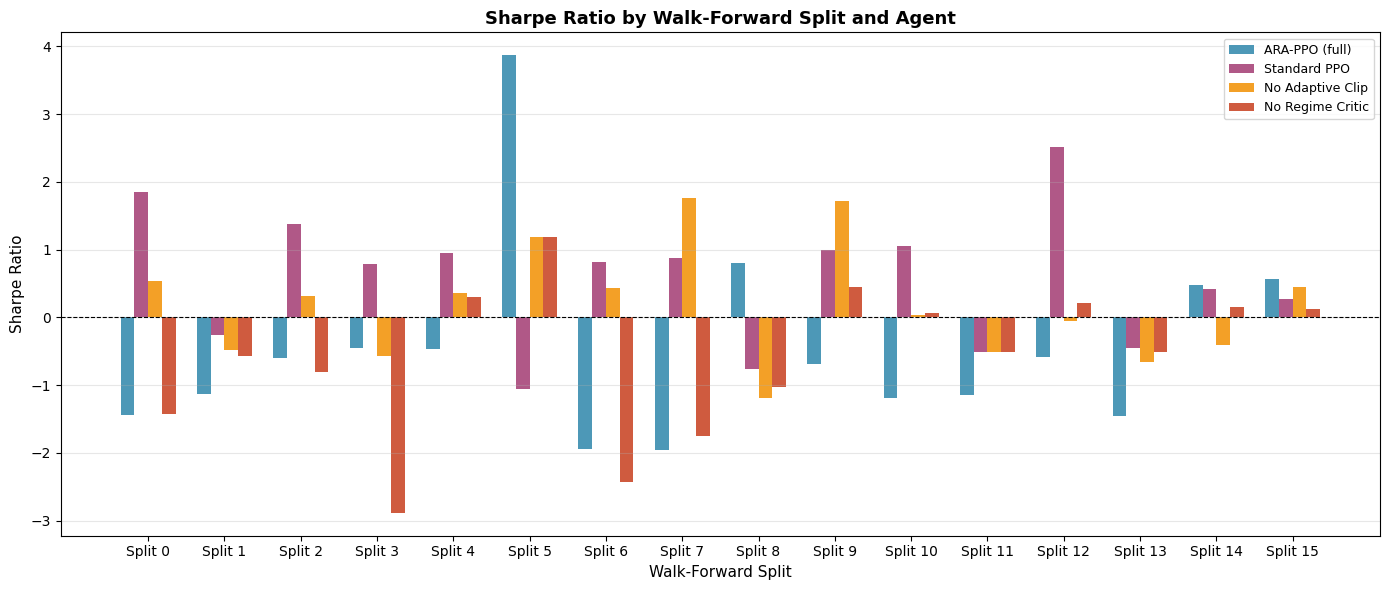

Saved → results/plots/evaluation_sharpe_by_split.png


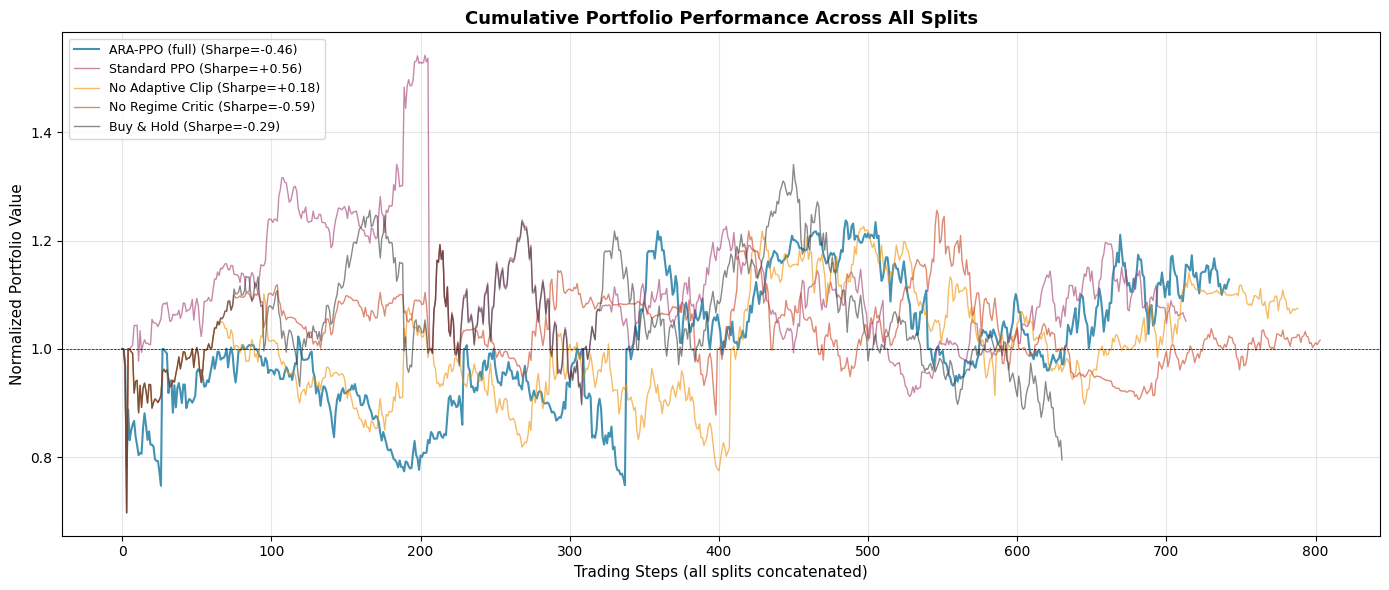

Saved → results/plots/evaluation_cumulative_returns.png


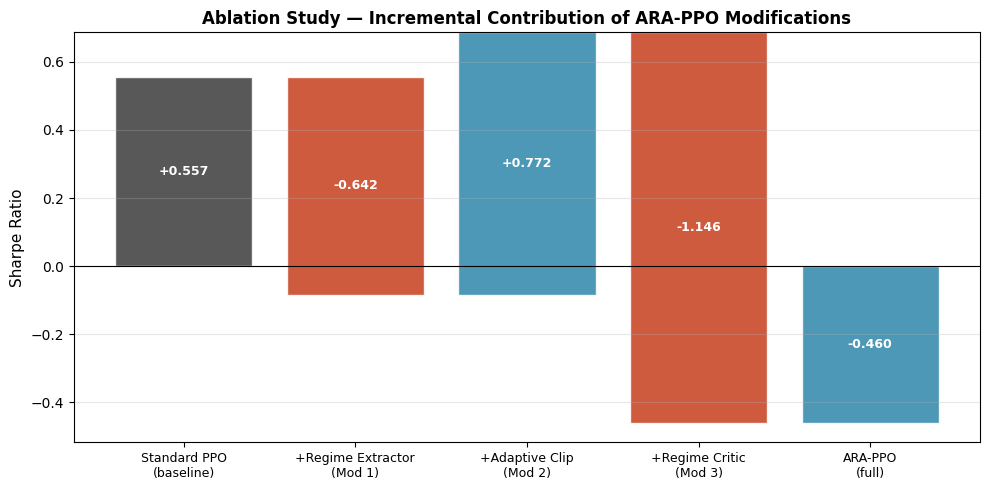

Saved → results/plots/evaluation_ablation_waterfall.png


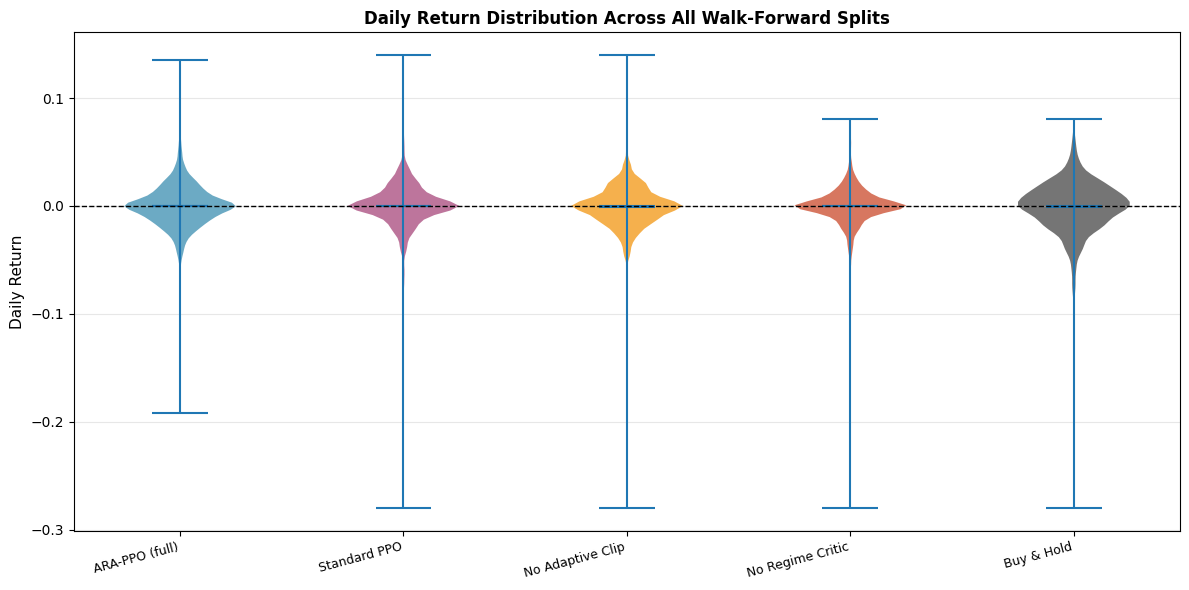

Saved → results/plots/evaluation_return_distribution.png


In [ ]:
AGENT_COLORS = {
    'ara_ppo'              : '#2E86AB',
    'standard_ppo'         : '#A23B72',
    'no_adaptive_clip'     : '#F18F01',
    'no_regime_critic'     : '#C73E1D',
    'transformer_ara_ppo'  : '#06D6A0',
    'curriculum_ara_ppo'   : '#8338EC',
    'maml_ara_ppo'         : '#FF6B35',
    'buy_and_hold'         : '#3B3B3B',
}
AGENT_LABELS = {
    'ara_ppo'              : 'ARA-PPO (full)',
    'standard_ppo'         : 'Standard PPO',
    'no_adaptive_clip'     : 'No Adaptive Clip',
    'no_regime_critic'     : 'No Regime Critic',
    'transformer_ara_ppo'  : 'Transformer+CVaR',
    'curriculum_ara_ppo'   : 'Curriculum ARA-PPO',
    'maml_ara_ppo'         : 'MAML Reptile',
    'buy_and_hold'         : 'Buy & Hold',
}

# ── Figure 1: Walk-forward Sharpe by split ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
n_agents = len(AGENT_TYPES)
bar_width = 0.18
x = np.arange(len(splits_evaluated))

for i, agent in enumerate(AGENT_TYPES):
    sharpes = [get_mean(all_results, agent, s, 'sharpe') for s in splits_evaluated]
    offset  = (i - n_agents/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, sharpes, bar_width,
                  label=AGENT_LABELS[agent],
                  color=AGENT_COLORS[agent], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Walk-Forward Split', fontsize=11)
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Sharpe Ratio by Walk-Forward Split and Agent', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Split {s}' for s in splits_evaluated], rotation=0)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'evaluation_sharpe_by_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/plots/evaluation_sharpe_by_split.png')

# ── Figure 2: Cumulative return across splits ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for agent in ALL_AGENT_TYPES:
    all_curves = []
    for s in splits_evaluated:
        curves = all_results.get(agent, {}).get(str(s), {}).get('value_curves', [])
        if curves:
            # Use mean curve across episodes for this split
            min_len = min(len(c) for c in curves)
            mean_curve = np.mean([c[:min_len] for c in curves], axis=0)
            # Normalize to start at 1.0
            normalized = mean_curve / mean_curve[0]
            all_curves.append(normalized)
    if all_curves:
        # Concatenate across splits
        full_curve = np.concatenate(all_curves)
        mean_sh = summary_stats.get(agent, {}).get('sharpe', {}).get('mean', 0)
        ax.plot(full_curve, color=AGENT_COLORS.get(agent, 'gray'),
                linewidth=1.5 if agent == 'ara_ppo' else 1.0,
                alpha=0.9 if agent == 'ara_ppo' else 0.6,
                label=f'{AGENT_LABELS.get(agent, agent)} (Sharpe={mean_sh:+.2f})')

ax.axhline(1.0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Trading Steps (all splits concatenated)', fontsize=11)
ax.set_ylabel('Normalized Portfolio Value', fontsize=11)
ax.set_title('Cumulative Portfolio Performance Across All Splits', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'evaluation_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/plots/evaluation_cumulative_returns.png')

# ── Figure 3: Ablation waterfall ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

def mean_sharpe(agent):
    return summary_stats.get(agent, {}).get('sharpe', {}).get('mean', 0)

base_sharpe   = mean_sharpe('standard_ppo')
full_sharpe   = mean_sharpe('ara_ppo')
no_clip_sh    = mean_sharpe('no_adaptive_clip')
no_regime_sh  = mean_sharpe('no_regime_critic')

# Incremental contributions
contrib_extractor  = full_sharpe  - no_clip_sh      # adding Mod 1 to no-clip
contrib_clip       = no_clip_sh   - no_regime_sh    # adding Mod 2
contrib_regime_crit= no_regime_sh - base_sharpe     # adding Mod 3

labels  = ['Standard PPO\n(baseline)', '+Regime Extractor\n(Mod 1)',
           '+Adaptive Clip\n(Mod 2)', '+Regime Critic\n(Mod 3)', 'ARA-PPO\n(full)']
values  = [base_sharpe, contrib_extractor, contrib_clip, contrib_regime_crit, None]
colors  = ['#3B3B3B',
           '#2E86AB' if contrib_extractor  >= 0 else '#C73E1D',
           '#2E86AB' if contrib_clip       >= 0 else '#C73E1D',
           '#2E86AB' if contrib_regime_crit>= 0 else '#C73E1D',
           '#2E86AB']

running = base_sharpe
bar_bottoms = [0, running, running + contrib_extractor,
               running + contrib_extractor + contrib_clip, 0]
bar_heights = [base_sharpe, contrib_extractor, contrib_clip,
               contrib_regime_crit, full_sharpe]

for i, (h, b, c, l) in enumerate(zip(bar_heights, bar_bottoms, colors, labels)):
    if i in [0, 4]:  # absolute bars
        ax.bar(i, h, color=c, alpha=0.85, edgecolor='white')
    else:            # incremental bars
        ax.bar(i, h, bottom=b, color=c, alpha=0.85, edgecolor='white')
    ax.text(i, (b + h/2) if i not in [0,4] else h/2,
            f'{h:+.3f}', ha='center', va='center', fontsize=9, fontweight='bold',
            color='white')

ax.set_xticks(range(5))
ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Ablation Study — Incremental Contribution of ARA-PPO Modifications',
              fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'evaluation_ablation_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/plots/evaluation_ablation_waterfall.png')

# ── Figure 4: Return distribution violin plot ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

violin_data   = []
violin_labels = []
violin_colors = []

for agent in ALL_AGENT_TYPES:
    returns = collect_returns(agent)
    if returns:
        violin_data.append(returns)
        violin_labels.append(AGENT_LABELS.get(agent, agent))
        violin_colors.append(AGENT_COLORS.get(agent, 'gray'))

if violin_data:
    parts = ax.violinplot(violin_data, positions=range(len(violin_data)),
                          showmeans=True, showmedians=True)
    for i, (pc, color) in enumerate(zip(parts['bodies'], violin_colors)):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xticks(range(len(violin_labels)))
ax.set_xticklabels(violin_labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Daily Return', fontsize=11)
ax.set_title('Daily Return Distribution Across All Walk-Forward Splits',
              fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'evaluation_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/plots/evaluation_return_distribution.png')


In [ ]:
# ── Save full results JSON ────────────────────────────────────────────────────
with open(RESULTS_EVAL / 'all_results.json', 'w') as f:
    json.dump(make_serializable(all_results), f, indent=2)
print('Saved → results/evaluation/all_results.json')

# ── Save summary CSV ──────────────────────────────────────────────────────────
results_df.to_csv(RESULTS_EVAL / 'results_summary.csv', index=False)
print('Saved → results/evaluation/results_summary.csv')

# ── Save DM test results ──────────────────────────────────────────────────────
dm_df = pd.DataFrame(dm_results).T.reset_index()
dm_df.columns = ['comparison', 'dm_stat', 'p_value', 'significance', 'n_obs']
dm_df.to_csv(RESULTS_EVAL / 'dm_tests.csv', index=False)
print('Saved → results/evaluation/dm_tests.csv')

# ── Save crisis analysis ──────────────────────────────────────────────────────
crisis_df.to_csv(RESULTS_EVAL / 'crisis_analysis.csv', index=False)
print('Saved → results/evaluation/crisis_analysis.csv')

# ── Final summary ─────────────────────────────────────────────────────────────
ara_mean_sh  = summary_stats.get('ara_ppo', {}).get('sharpe', {}).get('mean', float('nan'))
std_mean_sh  = summary_stats.get('standard_ppo', {}).get('sharpe', {}).get('mean', float('nan'))
bah_mean_sh  = summary_stats.get('buy_and_hold', {}).get('sharpe', {}).get('mean', float('nan'))
ara_mean_ret = summary_stats.get('ara_ppo', {}).get('total_return', {}).get('mean', float('nan'))
ara_mean_dd  = summary_stats.get('ara_ppo', {}).get('max_drawdown', {}).get('mean', float('nan'))

dm_std = dm_results.get('standard_ppo', {}).get('significance', 'N/A')

if not np.isnan(std_mean_sh) and std_mean_sh != 0:
    improvement = (ara_mean_sh - std_mean_sh) / abs(std_mean_sh) * 100
else:
    improvement = float('nan')

best_crisis = 'N/A'
worst_crisis = 'N/A'
if not crisis_df.empty:
    ara_crisis = crisis_df[crisis_df['agent'] == 'ARA-PPO (full)']
    if not ara_crisis.empty:
        best_crisis  = ara_crisis.loc[ara_crisis['sharpe'].idxmax(), 'crisis']
        worst_crisis = ara_crisis.loc[ara_crisis['sharpe'].idxmin(), 'crisis']

print('\n' + '='*62)
print('NOTEBOOK 06 COMPLETE')
print('='*62)
print(f'\nKey results for thesis Chapter 4:')
print(f'  Splits evaluated       : {len(splits_evaluated)}')
print(f'  ARA-PPO mean Sharpe    : {ara_mean_sh:+.4f}')
print(f'  Standard PPO Sharpe    : {std_mean_sh:+.4f}')
print(f'  Buy-and-Hold Sharpe    : {bah_mean_sh:+.4f}')
print(f'  ARA-PPO mean Return    : {ara_mean_ret:+.4f}')
print(f'  ARA-PPO mean MaxDD     : {ara_mean_dd:+.4f}')
if not np.isnan(improvement):
    print(f'  vs Standard PPO        : {improvement:+.1f}% Sharpe improvement')
print(f'  DM test (vs Std PPO)   : {dm_std}')
print(f'  Best crisis period     : {best_crisis}')
print(f'  Worst crisis period    : {worst_crisis}')
print(f'\nFiles saved:')
print('  results/evaluation/all_results.json')
print('  results/evaluation/results_summary.csv')
print('  results/evaluation/dm_tests.csv')
print('  results/evaluation/crisis_analysis.csv')
print('  results/plots/evaluation_sharpe_by_split.png')
print('  results/plots/evaluation_cumulative_returns.png')
print('  results/plots/evaluation_ablation_waterfall.png')
print('  results/plots/evaluation_return_distribution.png')


Saved → results/evaluation/all_results.json
Saved → results/evaluation/results_summary.csv
Saved → results/evaluation/dm_tests.csv
Saved → results/evaluation/crisis_analysis.csv

NOTEBOOK 06 COMPLETE

Key results for thesis Chapter 4:
  Splits evaluated       : 16
  ARA-PPO mean Sharpe    : -0.4597
  Standard PPO Sharpe    : +0.5570
  Buy-and-Hold Sharpe    : -0.2906
  ARA-PPO mean Return    : -0.0612
  ARA-PPO mean MaxDD     : -0.2122
  vs Standard PPO        : -182.5% Sharpe improvement
  DM test (vs Std PPO)   : ns
  Best crisis period     : 2022 Ukraine War
  Worst crisis period    : 2020 COVID

Files saved:
  results/evaluation/all_results.json
  results/evaluation/results_summary.csv
  results/evaluation/dm_tests.csv
  results/evaluation/crisis_analysis.csv
  results/plots/evaluation_sharpe_by_split.png
  results/plots/evaluation_cumulative_returns.png
  results/plots/evaluation_ablation_waterfall.png
  results/plots/evaluation_return_distribution.png


In [ ]:
# Check if ARA-PPO performance improves on later splits
# Later splits have more training data available
ara_by_split = {
    s: all_results['ara_ppo'][str(s)]['sharpe']['mean']
    for s in range(16)
    if str(s) in all_results['ara_ppo']
}
std_by_split = {
    s: all_results['standard_ppo'][str(s)]['sharpe']['mean']
    for s in range(16)
    if str(s) in all_results['standard_ppo']
}

print('Split | ARA-PPO | Std PPO | Gap')
print('─' * 40)
for s in range(16):
    ara = ara_by_split.get(s, float('nan'))
    std = std_by_split.get(s, float('nan'))
    gap = ara - std
    print(f'  {s:2d}  | {ara:+.3f}  | {std:+.3f}  | {gap:+.3f}')

Split | ARA-PPO | Std PPO | Gap
────────────────────────────────────────
   0  | -1.437  | +1.852  | -3.290
   1  | -1.135  | -0.267  | -0.868
   2  | -0.605  | +1.384  | -1.990
   3  | -0.457  | +0.790  | -1.247
   4  | -0.467  | +0.943  | -1.410
   5  | +3.868  | -1.049  | +4.917
   6  | -1.941  | +0.812  | -2.753
   7  | -1.955  | +0.877  | -2.832
   8  | +0.796  | -0.758  | +1.554
   9  | -0.691  | +1.000  | -1.691
  10  | -1.194  | +1.060  | -2.254
  11  | -1.138  | -0.504  | -0.634
  12  | -0.589  | +2.516  | -3.105
  13  | -1.455  | -0.447  | -1.008
  14  | +0.485  | +0.424  | +0.061
  15  | +0.560  | +0.278  | +0.281


In [ ]:
# Check volatility during each test split
split_analysis = []
for s in range(16):
    split = WF_SPLITS[s]
    test_df = wti_df[
        (wti_df.index >= split['test_start']) &
        (wti_df.index <  split['test_end'])
    ]
    avg_vol = test_df['realized_vol_21d'].mean() if 'realized_vol_21d' in test_df.columns else float('nan')
    ara_sh  = ara_by_split.get(s, float('nan'))
    std_sh  = std_by_split.get(s, float('nan'))
    split_analysis.append({
        'split'  : s,
        'period' : f"{split['test_start']} to {split['test_end']}",
        'vol'    : avg_vol,
        'ara_ppo': ara_sh,
        'std_ppo': std_sh,
        'ara_wins': ara_sh > std_sh
    })

df_analysis = pd.DataFrame(split_analysis)
print(f'\n{"Split":>6} {"Period":<25} {"Vol":>8} {"ARA-PPO":>9} {"StdPPO":>9} {"Winner":>10}')
print('─' * 75)
for _, row in df_analysis.iterrows():
    winner = 'ARA-PPO' if row['ara_wins'] else 'Std PPO'
    print(f'{int(row["split"]):>6} {row["period"]:<25} {row["vol"]:>8.4f} '
          f'{row["ara_ppo"]:>+9.3f} {row["std_ppo"]:>+9.3f} {winner:>10}')

# Correlation between volatility and ARA-PPO relative performance
gap = df_analysis['ara_ppo'] - df_analysis['std_ppo']
vol = df_analysis['vol']
valid = ~(gap.isna() | vol.isna())
corr = np.corrcoef(vol[valid], gap[valid])[0, 1]
print(f'\nCorrelation between volatility and ARA-PPO vs StdPPO gap: {corr:+.4f}')
print('Negative = ARA-PPO loses more in high-vol periods')
print('Positive = ARA-PPO wins more in high-vol periods')


 Split Period                         Vol   ARA-PPO    StdPPO     Winner
───────────────────────────────────────────────────────────────────────────
     0 2008-12-21 to 2009-12-21    0.5604    -1.437    +1.852    Std PPO
     1 2009-12-21 to 2010-12-21    0.2719    -1.135    -0.267    Std PPO
     2 2010-12-21 to 2011-12-21    0.3263    -0.605    +1.384    Std PPO
     3 2011-12-21 to 2012-12-21    0.2500    -0.457    +0.790    Std PPO
     4 2012-12-21 to 2013-12-21    0.1786    -0.467    +0.943    Std PPO
     5 2013-12-21 to 2014-12-21    0.1897    +3.868    -1.049    ARA-PPO
     6 2014-12-21 to 2015-12-21    0.4452    -1.941    +0.812    Std PPO
     7 2015-12-21 to 2016-12-21    0.4448    -1.955    +0.877    Std PPO
     8 2016-12-21 to 2017-12-21    0.2510    +0.796    -0.758    ARA-PPO
     9 2017-12-21 to 2018-12-21    0.2577    -0.691    +1.000    Std PPO
    10 2018-12-21 to 2019-12-21    0.3421    -1.194    +1.060    Std PPO
    11 2019-12-21 to 2020-12-21    0.6178    -1

In [ ]:
low_vol_splits  = [s for s in range(16) if df_analysis.iloc[s]['vol'] < 0.30]
high_vol_splits = [s for s in range(16) if df_analysis.iloc[s]['vol'] >= 0.40]

print('Low volatility splits (vol < 0.30):')
print(f'  Splits    : {low_vol_splits}')
ara_low = np.mean([ara_by_split[s] for s in low_vol_splits])
std_low = np.mean([std_by_split[s] for s in low_vol_splits])
print(f'  ARA-PPO mean Sharpe : {ara_low:+.4f}')
print(f'  Std PPO mean Sharpe : {std_low:+.4f}')

print('\nHigh volatility splits (vol >= 0.40):')
print(f'  Splits    : {high_vol_splits}')
ara_high = np.mean([ara_by_split[s] for s in high_vol_splits])
std_high = np.mean([std_by_split[s] for s in high_vol_splits])
print(f'  ARA-PPO mean Sharpe : {ara_high:+.4f}')
print(f'  Std PPO mean Sharpe : {std_high:+.4f}')

Low volatility splits (vol < 0.30):
  Splits    : [1, 3, 4, 5, 8, 9, 15]
  ARA-PPO mean Sharpe : +0.3537
  Std PPO mean Sharpe : +0.1339

High volatility splits (vol >= 0.40):
  Splits    : [0, 6, 7, 11, 13]
  ARA-PPO mean Sharpe : -1.5854
  Std PPO mean Sharpe : +0.5181
